# Packages used:

- pandas, numpy, matplotlib, statsmodel, pandas_datareader, datetime, yfinance, sklearn, PyPortfolioOpt

# Download SP500 stocks prices data


In [1]:
from statsmodels.regression.rolling import RollingOLS
import pandas_datareader.data as web
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
import numpy as np
import datetime as dt
import yfinance as yf
import pandas_ta
#it is a specialised finance-indicator
#calculates RSI, MACD, Bollinger Bands, and Moving Averages
import warnings
warnings.filterwarnings('ignore')
import requests
from io import StringIO

url='https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}

response= requests.get(url, headers=headers)
response.raise_for_status()

tables= pd.read_html(StringIO(response.text))
sp500=tables[0]
sp500.head()

sp500['Symbol']= sp500['Symbol'].str.replace('.', '-')
#.str enables string-manipulation for the entire column

symbols_list = sp500['Symbol'].unique().tolist()
delisted_stock = ['EVRG', 'HONA', 'GEV', 'FDXF', 'SOLV', 'VLTO', 'SNDK', 'Q']


for symbol in delisted_stock:
    if symbol in symbols_list:
        symbols_list.remove(symbol)

end_date = '2023-09-27'

start_date = pd.to_datetime(end_date)-pd.DateOffset(365*8)

df = yf.download(tickers=symbols_list,
                 start = start_date,
                 end = end_date)


df.stack()

print(df.columns)
print(df.columns.duplicated().sum())
df = df.stack(level='Ticker').sort_index()
df.index.names = ['date', 'ticker']  # adjust based on your actual index order

df.columns = df.columns.str.lower()

df

[*********************100%***********************]  495 of 495 completed


MultiIndex([( 'Close',    'A'),
            ( 'Close', 'AAPL'),
            ( 'Close', 'ABBV'),
            ( 'Close', 'ABNB'),
            ( 'Close',  'ABT'),
            ( 'Close', 'ACGL'),
            ( 'Close',  'ACN'),
            ( 'Close', 'ADBE'),
            ( 'Close',  'ADI'),
            ( 'Close',  'ADM'),
            ...
            ('Volume',   'WY'),
            ('Volume', 'WYNN'),
            ('Volume',  'XEL'),
            ('Volume',  'XOM'),
            ('Volume',  'XYL'),
            ('Volume',  'XYZ'),
            ('Volume',  'YUM'),
            ('Volume',  'ZBH'),
            ('Volume', 'ZBRA'),
            ('Volume',  'ZTS')],
           names=['Price', 'Ticker'], length=2475)
0


Price                   close        high         low        open       volume
date       ticker                                                             
2015-09-29 A        30.937080   31.230496   30.478617   30.588648    2252400.0
           AAPL     24.439426   25.436635   24.170517   25.284253  293461600.0
           ABBV     33.955017   34.855509   33.369697   34.154410   12842800.0
           ABNB           NaN         NaN         NaN         NaN          NaN
           ABT      32.163700   32.692977   31.780992   31.968274   12287500.0
...                       ...         ...         ...         ...          ...
2023-09-26 XYZ      44.810001   45.740002   44.560001   44.939999   10168200.0
           YUM     117.599335  118.291593  117.068279  117.817441    1500600.0
           ZBH     109.363075  113.885025  109.324176  113.554384    3610500.0
           ZBRA    223.960007  226.649994  222.580002  225.970001     355400.0
           ZTS     170.949066  172.476176  170.369161  170.668781    1463200.0

[995940 rows x 5 columns]

# Calculate features and technical indicators for each stock

- German-Klass Volatility
- RSI
- Bollinger Bands
- ATR
- MACD
- Dollar Volume


$$\text{Garman-Klass Volatility} = \frac{(\ln(\text{High}) - \ln(\text{Low}))^2}{2} - (2 \ln(2) - 1)(\ln(\text{Adj Close}) - \ln(\text{Open}))^2$$


Price                   close        high         low        open  \
date       ticker                                                   
2015-09-29 A        30.937080   31.230496   30.478617   30.588648   
           AAPL     24.439426   25.436635   24.170517   25.284253   
           ABBV     33.955017   34.855509   33.369697   34.154410   
           ABNB           NaN         NaN         NaN         NaN   
           ABT      32.163700   32.692977   31.780992   31.968274   
...                       ...         ...         ...         ...   
2023-09-26 XYZ      44.810001   45.740002   44.560001   44.939999   
           YUM     117.599335  118.291593  117.068279  117.817441   
           ZBH     109.363075  113.885025  109.324176  113.554384   
           ZBRA    223.960007  226.649994  222.580002  225.970001   
           ZTS     170.949066  172.476176  170.369161  170.668781   

Price                   volume  garman_klass_vol        rsi  
date       ticker                                            
2015-09-29 A         2252400.0          0.000247        NaN  
           AAPL    293461600.0          0.000857        NaN  
           ABBV     12842800.0          0.000936        NaN  
           ABNB            NaN               NaN        NaN  
           ABT      12287500.0          0.000386        NaN  
...                        ...               ...        ...  
2023-09-26 XYZ      10168200.0          0.000338  25.939817  
           YUM       1500600.0          0.000053  36.057190  
           ZBH       3610500.0          0.000289  31.893263  
           ZBRA       355400.0          0.000133  29.494977  
           ZTS       1463200.0          0.000075  42.623507  

[995940 rows x 7 columns]

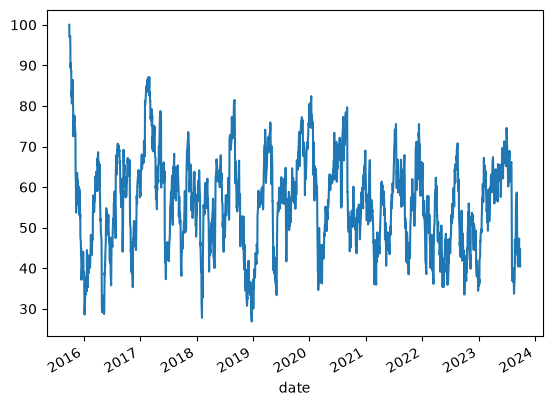

In [2]:
df['garman_klass_vol'] = ((np.log(df['high'])-np.log(df['low']))**2)/2 - (2*np.log(2)-1)*((np.log(df['close'])-np.log(df['open']))**2)




df['rsi'] = df.groupby(level=1)['close'].transform(lambda x: pandas_ta.rsi(close=x, length=20))

df.xs('AAPL', level=1)['rsi'].plot()

df

In [3]:
df['bb_low'] = df.groupby(level=1)['close'].transform(lambda x: pandas_ta.bbands(close=np.log1p(x), length=20).iloc[:, 0])
df['bb_mid'] = df.groupby(level=1)['close'].transform(lambda x: pandas_ta.bbands(close=np.log1p(x), length=20).iloc[:, 1])
df['bb_high'] = df.groupby(level=1)['close'].transform(lambda x: pandas_ta.bbands(close=np.log1p(x), length=20).iloc[:, 2])

In [4]:
def compute_atr(stock_data):
    atr= pandas_ta.atr(high = stock_data['high'],
                       low = stock_data['low'],
                       close=stock_data['close'],
                       length =14)
    return atr.sub(atr.mean()).div(atr.std())

df['atr'] = df.groupby(level=1, group_keys=False).apply(compute_atr)

df

Price                   close        high         low        open  \
date       ticker                                                   
2015-09-29 A        30.937080   31.230496   30.478617   30.588648   
           AAPL     24.439426   25.436635   24.170517   25.284253   
           ABBV     33.955017   34.855509   33.369697   34.154410   
           ABNB           NaN         NaN         NaN         NaN   
           ABT      32.163700   32.692977   31.780992   31.968274   
...                       ...         ...         ...         ...   
2023-09-26 XYZ      44.810001   45.740002   44.560001   44.939999   
           YUM     117.599335  118.291593  117.068279  117.817441   
           ZBH     109.363075  113.885025  109.324176  113.554384   
           ZBRA    223.960007  226.649994  222.580002  225.970001   
           ZTS     170.949066  172.476176  170.369161  170.668781   

Price                   volume  garman_klass_vol        rsi    bb_low  \
date       ticker                                                       
2015-09-29 A         2252400.0          0.000247        NaN       NaN   
           AAPL    293461600.0          0.000857        NaN       NaN   
           ABBV     12842800.0          0.000936        NaN       NaN   
           ABNB            NaN               NaN        NaN       NaN   
           ABT      12287500.0          0.000386        NaN       NaN   
...                        ...               ...        ...       ...   
2023-09-26 XYZ      10168200.0          0.000338  25.939817  3.794872   
           YUM       1500600.0          0.000053  36.057190  4.772782   
           ZBH       3610500.0          0.000289  31.893263  4.725363   
           ZBRA       355400.0          0.000133  29.494977  5.397402   
           ZTS       1463200.0          0.000075  42.623507  5.128190   

Price                bb_mid   bb_high       atr  
date       ticker                                
2015-09-29 A            NaN       NaN       NaN  
           AAPL         NaN       NaN       NaN  
           ABBV         NaN       NaN       NaN  
           ABNB         NaN       NaN       NaN  
           ABT          NaN       NaN       NaN  
...                     ...       ...       ...  
2023-09-26 XYZ     3.980555  4.166238 -0.644688  
           YUM     4.803516  4.834250  0.271487  
           ZBH     4.766053  4.806743 -0.317195  
           ZBRA    5.539167  5.680932 -0.057038  
           ZTS     5.188523  5.248855  0.688632  

[995940 rows x 11 columns]

In [5]:
def compute_macd(close):
    macd = pandas_ta.macd(close = close, length = 20).iloc[:, 0]
    return macd.sub(macd.mean()).div(macd.std())

df['macd'] = df.groupby(level=1, group_keys=False)['close'].apply(compute_macd)

In [6]:
df['dollar_volume'] = (df['close']*df['volume'])/1e6

df

Price                   close        high         low        open  \
date       ticker                                                   
2015-09-29 A        30.937080   31.230496   30.478617   30.588648   
           AAPL     24.439426   25.436635   24.170517   25.284253   
           ABBV     33.955017   34.855509   33.369697   34.154410   
           ABNB           NaN         NaN         NaN         NaN   
           ABT      32.163700   32.692977   31.780992   31.968274   
...                       ...         ...         ...         ...   
2023-09-26 XYZ      44.810001   45.740002   44.560001   44.939999   
           YUM     117.599335  118.291593  117.068279  117.817441   
           ZBH     109.363075  113.885025  109.324176  113.554384   
           ZBRA    223.960007  226.649994  222.580002  225.970001   
           ZTS     170.949066  172.476176  170.369161  170.668781   

Price                   volume  garman_klass_vol        rsi    bb_low  \
date       ticker                                                       
2015-09-29 A         2252400.0          0.000247        NaN       NaN   
           AAPL    293461600.0          0.000857        NaN       NaN   
           ABBV     12842800.0          0.000936        NaN       NaN   
           ABNB            NaN               NaN        NaN       NaN   
           ABT      12287500.0          0.000386        NaN       NaN   
...                        ...               ...        ...       ...   
2023-09-26 XYZ      10168200.0          0.000338  25.939817  3.794872   
           YUM       1500600.0          0.000053  36.057190  4.772782   
           ZBH       3610500.0          0.000289  31.893263  4.725363   
           ZBRA       355400.0          0.000133  29.494977  5.397402   
           ZTS       1463200.0          0.000075  42.623507  5.128190   

Price                bb_mid   bb_high       atr      macd  dollar_volume  
date       ticker                                                         
2015-09-29 A            NaN       NaN       NaN       NaN      69.682680  
           AAPL         NaN       NaN       NaN       NaN    7172.033181  
           ABBV         NaN       NaN       NaN       NaN     436.077493  
           ABNB         NaN       NaN       NaN       NaN            NaN  
           ABT          NaN       NaN       NaN       NaN     395.211465  
...                     ...       ...       ...       ...            ...  
2023-09-26 XYZ     3.980555  4.166238 -0.644688 -0.995289     455.637056  
           YUM     4.803516  4.834250  0.271487 -1.363696     176.469562  
           ZBH     4.766053  4.806743 -0.317195 -0.881067     394.855383  
           ZBRA    5.539167  5.680932 -0.057038 -1.600791      79.595386  
           ZTS     5.188523  5.248855  0.688632 -1.188277     250.132674  

[995940 rows x 13 columns]

# Aggregate to monthly level and filter top 150 most liquid stocks for each month

- To reduce training time and experiment with features and strategies, we convert the business-daily data to month-end frequency


In [7]:
last_cols = [c for c in df.columns.unique(0) if c not in ['dollar_volume', 'volume', 'open', 'high', 'low']]

data = (pd.concat([df.unstack('ticker')['dollar_volume'].resample('ME').mean().stack('ticker').to_frame('dollar_volume'),
                   df.unstack()[last_cols].resample('ME').last().stack('ticker')],
                   axis=1)).dropna()

data

dollar_volume       close  garman_klass_vol        rsi  \
date       ticker                                                           
2015-11-30 A          133.632313   38.345840          0.000050  76.845924   
           AAPL      3989.425851   26.623512          0.000095  60.140501   
           ABBV       315.454033   37.747826          0.000362  57.773887   
           ABT        203.345367   36.789444          0.000043  64.475850   
           ACGL        28.174423   22.970539          0.000078  39.865158   
...                          ...         ...               ...        ...   
2023-09-30 XYZ        581.673532   44.810001          0.000338  25.939817   
           YUM        168.459159  117.599335          0.000053  36.057190   
           ZBH        187.678656  109.363075          0.000289  31.893263   
           ZBRA       105.780863  223.960007          0.000133  29.494977   
           ZTS        280.039960  170.949066          0.000075  42.623507   

                     bb_low    bb_mid   bb_high       atr      macd  
date       ticker                                                    
2015-11-30 A       3.527108  3.601404  3.675700 -1.042002  0.567157  
           AAPL    3.272254  3.316677  3.361100 -0.970804 -0.142789  
           ABBV    3.659386  3.708808  3.758230 -0.754521  0.145677  
           ABT     3.616473  3.638871  3.661269 -1.085248  0.335557  
           ACGL    3.177527  3.195190  3.212853 -1.147609 -0.550166  
...                     ...       ...       ...       ...       ...  
2023-09-30 XYZ     3.794872  3.980555  4.166238 -0.644688 -0.995289  
           YUM     4.772782  4.803516  4.834250  0.271487 -1.363696  
           ZBH     4.725363  4.766053  4.806743 -0.317195 -0.881067  
           ZBRA    5.397402  5.539167  5.680932 -0.057038 -1.600791  
           ZTS     5.128190  5.188523  5.248855  0.688632 -1.188277  

[45714 rows x 9 columns]

- Calculate 5-year rolling average of dollar volume for each stocks before filtering


In [8]:
data['dollar_volume'] = (data.loc[:, 'dollar_volume'].unstack('ticker').rolling(5*12, min_periods=12).mean().stack())

data['dollar_vol_rank'] = (data.groupby('date')['dollar_volume'].rank(ascending = False))

data = data[data['dollar_vol_rank']<150].drop(['dollar_volume', 'dollar_vol_rank'], axis=1)

data


close  garman_klass_vol        rsi    bb_low  \
date       ticker                                                      
2016-10-31 AAPL     25.987356          0.000041  49.891097  3.285183   
           ABBV     37.609138          0.000192  27.477940  3.685941   
           ABT      32.946442          0.000024  38.008867  3.514418   
           ACN     100.402321          0.000033  53.823768  4.606287   
           ADBE    107.510002          0.000059  53.668497  4.679120   
...                       ...               ...        ...       ...   
2023-09-30 WDAY    229.240005          0.000141  43.976804  5.435794   
           WFC      38.013245          0.000234  40.920251  3.651702   
           WMT      52.612854          0.000024  54.722600  3.966327   
           XOM     106.167862          0.000045  59.440191  4.621021   
           XYZ      44.810001          0.000338  25.939817  3.794872   

                     bb_mid   bb_high       atr      macd  
date       ticker                                          
2016-10-31 AAPL    3.314804  3.344425 -1.035925 -0.195978  
           ABBV    3.741424  3.796906 -0.985604 -0.760593  
           ABT     3.566146  3.617874 -1.054091 -0.650890  
           ACN     4.618223  4.630159 -0.999572 -0.135456  
           ADBE    4.694639  4.710159 -1.230019 -0.109039  
...                     ...       ...       ...       ...  
2023-09-30 WDAY    5.495242  5.554691 -0.127898 -0.306858  
           WFC     3.693068  3.734435 -0.227160 -0.282325  
           WMT     3.984245  4.002162 -0.075186  0.399460  
           XOM     4.662133  4.703246  0.886271  1.400623  
           XYZ     3.980555  4.166238 -0.644688 -0.995289  

[12516 rows x 8 columns]

# Calculate monthly returns for different time horizons as features

- To capture time series dynamics that reflect, for example, momentum patterns, we compute historical returns using the method .pct_change(lag), that is, returns over various monthly periods as identified by lags


Percentage Change: Calculates the raw total return over the lag period.
Formula:
$$ \frac{\text{Close}_{\text{today}} - \text{Close}_{\text{past}}}{\text{Close}\_{\text{past}}} $$


Geometric Normalization: Converts the multi-month return into a per-month compounded rate.Formula:
$\left( 1 + \text{Return} \right)^{\frac{1}{\text{lag}}} - 1$

Example: If a stock gains 21% over a lag of 2 months, it computes \((1 + 0.21)^{1/2} - 1 = 10\%\) return per month.


In [9]:
def calculate_returns(df):
    outlier_cutoff = 0.005
    lags = [1, 2, 3, 6, 9, 12]
    for lag in lags:
        df[f'return_{lag}m'] = (df['close']
                                .pct_change(lag)
                                .pipe(lambda x: x.clip(lower = x.quantile(outlier_cutoff),
                                                       upper=x.quantile(1-outlier_cutoff)))
                                .add(1).pow(1/lag).sub(1))
    return df

data = data.groupby(level=1, group_keys = False).apply(calculate_returns).dropna()

data

close  garman_klass_vol        rsi    bb_low  \
date       ticker                                                      
2017-10-31 AAPL     39.372829          0.000112  69.196743  3.585125   
           ABBV     63.070587          0.000173  55.247867  4.128810   
           ABT      46.588608          0.000036  53.844812  3.852718   
           ACN     125.442474          0.000019  69.365179  4.770844   
           ADBE    175.160004          0.000067  70.089317  4.948186   
...                       ...               ...        ...       ...   
2023-09-30 WDAY    229.240005          0.000141  43.976804  5.435794   
           WFC      38.013245          0.000234  40.920251  3.651702   
           WMT      52.612854          0.000024  54.722600  3.966327   
           XOM     106.167862          0.000045  59.440191  4.621021   
           XYZ      44.810001          0.000338  25.939817  3.794872   

                     bb_mid   bb_high       atr      macd  return_1m  \
date       ticker                                                      
2017-10-31 AAPL    3.633204  3.681284 -0.906602 -0.039276   0.096807   
           ABBV    4.176327  4.223845  0.054414  0.473814   0.022728   
           ABT     3.876880  3.901043 -1.040045  0.276133   0.021276   
           ACN     4.811544  4.852244 -0.977501  0.352341   0.064180   
           ADBE    5.089292  5.230398 -0.887926  0.612102   0.174152   
...                     ...       ...       ...       ...        ...   
2023-09-30 WDAY    5.495242  5.554691 -0.127898 -0.306858  -0.062413   
           WFC     3.693068  3.734435 -0.227160 -0.282325  -0.015500   
           WMT     3.984245  4.002162 -0.075186  0.399460  -0.000676   
           XOM     4.662133  4.703246  0.886271  1.400623   0.046947   
           XYZ     3.980555  4.166238 -0.644688 -0.995289  -0.222723   

                   return_2m  return_3m  return_6m  return_9m  return_12m  
date       ticker                                                          
2017-10-31 AAPL     0.015249   0.044955   0.028875   0.038941    0.035228  
           ABBV     0.098590   0.091379   0.056495   0.047273    0.044026  
           ABT      0.034308   0.034801   0.038672   0.031320    0.029294  
           ACN      0.048454   0.037203   0.028692   0.027398    0.018728  
           ADBE     0.062497   0.061392   0.045993   0.049515    0.041515  
...                      ...        ...        ...        ...         ...  
2023-09-30 WDAY    -0.016777   0.004919   0.017531   0.035597    0.034709  
           WFC     -0.057917  -0.013554   0.016712   0.000703    0.003255  
           WMT      0.010014   0.012354   0.017574   0.016553    0.020256  
           XOM      0.046139   0.030496   0.012838   0.008747    0.027037  
           XYZ     -0.247423  -0.123607  -0.068630  -0.036876   -0.016915  

[10313 rows x 14 columns]

# Download Fama-French Factors and calculate Rolling Factor Betas

- we will introduce the Fama-French data to estimate the exposure of assets to common risk factors using linear regression
- The five Fama-French factors, namely market risk, size, value, operating profitability, and investment have been shown empirically to explain asset returns and commonly used to assess the risk/return profile of portfolios.Hence, it is natural to include past factor exposures as financial features in models.
- We can assess the historical factor returns using the pandas-datareader and estimate historical exposure using the RollingOLS rolling linear regression


1. Mkt-RF (Market Risk Premium)What it stands for: _Market minus Risk-Free Rate._ The Formula: _The return of the total stock market minus the return of a risk-free investment_ (like a US 1-Month Treasury Bill).The Concept: It measures the extra return investors demand for choosing risky stocks over a guaranteed risk-free government asset. This is the foundational risk metric inherited from the classic Capital Asset Pricing Model (CAPM).
2. SMB (Small Minus Big)What it stands for: _Small Market Capitalisation minus Big Market Capitalisation._ The Formula: *The average return of small-cap stock portfolios minus the average return of large-cap stock portfolios.*The Concept: This represents the Size Premium. Historically, smaller companies tend to outperform larger corporations over long horizons because they are riskier, less liquid, and have higher growth potential.
3. HML (High Minus Low)What it stands for: _High Book-to-Market Ratio minus Low Book-to-Market Ratio._ The Formula: _The average return of value portfolios minus the average return of growth portfolios._ The Concept: This represents the Value Premium.High book-to-market companies are "Value stocks" (publicly traded cheap relative to their accounting worth).Low book-to-market companies are "Growth stocks" (highly priced due to future expansion expectations).HML tracks the historical outperformance of unloved value stocks over hyped growth stocks.
4. RMW (Robust Minus Weak)What it stands for: _Robust Operating Profitability minus Weak Operating Profitability._ The Formula: _The average return of companies with high, stable operating profits minus companies with low or negative earnings._ The Concept: This represents the Profitability/Quality Premium. Firms that generate high operating profit margins relative to their book equity historically provide more resilient, higher long-term returns to investors.
5. CMA (Conservative Minus Aggressive)What it stands for: _Conservative Total Investment minus Aggressive Total Investment._ The Formula: _The average return of firms that invest conservatively back into their business minus firms that invest aggressively._ The Concept: This represents the Investment Style Premium. Companies that scale their assets carefully and conservatively typically outperform "aggressive" spenders that dilute capital through massive asset growth, major mergers, or heavy capital expenditures.


In [10]:
factor_data = web.DataReader('F-F_Research_Data_5_Factors_2x3',
                             'famafrench',
                             start='2010')[0].drop('RF', axis=1)

factor_data.index = factor_data.index.to_timestamp()

factor_data =factor_data.resample('ME').last().div(100)
#changes 2010-01-01 to 2010-01-31

factor_data.index.name = 'date'

factor_data = factor_data.join(data['return_1m']).sort_index()

# note that the factors are same even though the returns are different

factor_data

Mkt-RF     SMB     HML     RMW     CMA  return_1m
date       ticker                                                   
2017-10-31 AAPL    0.0225 -0.0191  0.0013  0.0092 -0.0314   0.096807
           ABBV    0.0225 -0.0191  0.0013  0.0092 -0.0314   0.022728
           ABT     0.0225 -0.0191  0.0013  0.0092 -0.0314   0.021276
           ACN     0.0225 -0.0191  0.0013  0.0092 -0.0314   0.064180
           ADBE    0.0225 -0.0191  0.0013  0.0092 -0.0314   0.174152
...                   ...     ...     ...     ...     ...        ...
2023-09-30 WDAY   -0.0523 -0.0177  0.0150  0.0185 -0.0075  -0.062413
           WFC    -0.0523 -0.0177  0.0150  0.0185 -0.0075  -0.015500
           WMT    -0.0523 -0.0177  0.0150  0.0185 -0.0075  -0.000676
           XOM    -0.0523 -0.0177  0.0150  0.0185 -0.0075   0.046947
           XYZ    -0.0523 -0.0177  0.0150  0.0185 -0.0075  -0.222723

[10313 rows x 6 columns]

- filter out stocks with less than 10 months of data


In [11]:
observations = factor_data.groupby(level=1).size()

valid_stocks = observations[observations >=10]

factor_data = factor_data[factor_data.index.get_level_values('ticker').isin(valid_stocks.index)]

factor_data

Mkt-RF     SMB     HML     RMW     CMA  return_1m
date       ticker                                                   
2017-10-31 AAPL    0.0225 -0.0191  0.0013  0.0092 -0.0314   0.096807
           ABBV    0.0225 -0.0191  0.0013  0.0092 -0.0314   0.022728
           ABT     0.0225 -0.0191  0.0013  0.0092 -0.0314   0.021276
           ACN     0.0225 -0.0191  0.0013  0.0092 -0.0314   0.064180
           ADBE    0.0225 -0.0191  0.0013  0.0092 -0.0314   0.174152
...                   ...     ...     ...     ...     ...        ...
2023-09-30 WDAY   -0.0523 -0.0177  0.0150  0.0185 -0.0075  -0.062413
           WFC    -0.0523 -0.0177  0.0150  0.0185 -0.0075  -0.015500
           WMT    -0.0523 -0.0177  0.0150  0.0185 -0.0075  -0.000676
           XOM    -0.0523 -0.0177  0.0150  0.0185 -0.0075   0.046947
           XYZ    -0.0523 -0.0177  0.0150  0.0185 -0.0075  -0.222723

[10295 rows x 6 columns]

- calculate Rolling Factor Betas


In [12]:
betas = (factor_data.groupby(level=1,
                             group_keys=False)
                             # return_1m is the dependent variable, rest of the columns are independent variable
                             #RollingOLS = Rolling Ordinary Least Square (we use a window where we calculate linear regn.)
                             .apply(lambda x: RollingOLS(endog = x['return_1m'], 
                                                         exog=sm.add_constant(x.drop('return_1m', axis=1)),
                                                         window = min(24, x.shape[0]), # 24 months
                                                         min_nobs=len (x.columns) + 1)
                                                         .fit(params_only=True)
                                                         .params
                                                         .drop('const', axis = 1)))

betas

Mkt-RF       SMB       HML       RMW       CMA
date       ticker                                                  
2017-10-31 AAPL         NaN       NaN       NaN       NaN       NaN
           ABBV         NaN       NaN       NaN       NaN       NaN
           ABT          NaN       NaN       NaN       NaN       NaN
           ACN          NaN       NaN       NaN       NaN       NaN
           ADBE         NaN       NaN       NaN       NaN       NaN
...                     ...       ...       ...       ...       ...
2023-09-30 WDAY    1.080190 -0.943618 -0.563835 -0.904882 -0.245142
           WFC     1.121108  0.239845  2.055354 -0.497009 -1.548512
           WMT     0.703933 -0.313715 -0.405905 -0.146030  0.502706
           XOM     0.983582 -1.132577  1.726274 -0.692187 -0.352858
           XYZ     2.416222  1.931104 -0.346129 -1.680660  0.483605

[10295 rows x 5 columns]

In [13]:
data = (data.join(betas.groupby('ticker').shift()))

In [21]:
factors = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']

data.loc[:, factors] = data.groupby('ticker', group_keys = False)[factors].apply(lambda x: x.fillna(x.mean()))

data = data.dropna()

data = data.drop('close', axis=1)

data.info()

data

<class 'pandas.DataFrame'>
MultiIndex: 10053 entries, (Timestamp('2017-10-31 00:00:00'), 'AAPL') to (Timestamp('2023-09-30 00:00:00'), 'XYZ')
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   garman_klass_vol  10053 non-null  float64
 1   rsi               10053 non-null  float64
 2   bb_low            10053 non-null  float64
 3   bb_mid            10053 non-null  float64
 4   bb_high           10053 non-null  float64
 5   atr               10053 non-null  float64
 6   macd              10053 non-null  float64
 7   return_1m         10053 non-null  float64
 8   return_2m         10053 non-null  float64
 9   return_3m         10053 non-null  float64
 10  return_6m         10053 non-null  float64
 11  return_9m         10053 non-null  float64
 12  return_12m        10053 non-null  float64
 13  Mkt-RF            10053 non-null  float64
 14  SMB               10053 non-null  float64
 15  HML               100

garman_klass_vol        rsi    bb_low    bb_mid   bb_high  \
date       ticker                                                              
2017-10-31 AAPL            0.000112  69.196743  3.585125  3.633204  3.681284   
           ABBV            0.000173  55.247867  4.128810  4.176327  4.223845   
           ABT             0.000036  53.844812  3.852718  3.876880  3.901043   
           ACN             0.000019  69.365179  4.770844  4.811544  4.852244   
           ADBE            0.000067  70.089317  4.948186  5.089292  5.230398   
...                             ...        ...       ...       ...       ...   
2023-09-30 WDAY            0.000141  43.976804  5.435794  5.495242  5.554691   
           WFC             0.000234  40.920251  3.651702  3.693068  3.734435   
           WMT             0.000024  54.722600  3.966327  3.984245  4.002162   
           XOM             0.000045  59.440191  4.621021  4.662133  4.703246   
           XYZ             0.000338  25.939817  3.794872  3.980555  4.166238   

                        atr      macd  return_1m  return_2m  return_3m  \
date       ticker                                                        
2017-10-31 AAPL   -0.906602 -0.039276   0.096807   0.015249   0.044955   
           ABBV    0.054414  0.473814   0.022728   0.098590   0.091379   
           ABT    -1.040045  0.276133   0.021276   0.034308   0.034801   
           ACN    -0.977501  0.352341   0.064180   0.048454   0.037203   
           ADBE   -0.887926  0.612102   0.174152   0.062497   0.061392   
...                     ...       ...        ...        ...        ...   
2023-09-30 WDAY   -0.127898 -0.306858  -0.062413  -0.016777   0.004919   
           WFC    -0.227160 -0.282325  -0.015500  -0.057917  -0.013554   
           WMT    -0.075186  0.399460  -0.000676   0.010014   0.012354   
           XOM     0.886271  1.400623   0.046947   0.046139   0.030496   
           XYZ    -0.644688 -0.995289  -0.222723  -0.247423  -0.123607   

                   return_6m  return_9m  return_12m    Mkt-RF       SMB  \
date       ticker                                                         
2017-10-31 AAPL     0.028875   0.038941    0.035228  1.280008 -0.257187   
           ABBV     0.056495   0.047273    0.044026  0.496716  0.387237   
           ABT      0.038672   0.031320    0.029294  0.837507 -0.208350   
           ACN      0.028692   0.027398    0.018728  1.199197 -0.139406   
           ADBE     0.045993   0.049515    0.041515  1.106921 -0.321920   
...                      ...        ...         ...       ...       ...   
2023-09-30 WDAY     0.017531   0.035597    0.034709  1.078390 -0.958283   
           WFC      0.016712   0.000703    0.003255  1.138605  0.256314   
           WMT      0.017574   0.016553    0.020256  0.743669 -0.257779   
           XOM      0.012838   0.008747    0.027037  1.007242 -1.088024   
           XYZ     -0.068630  -0.036876   -0.016915  2.423639  1.931716   

                        HML       RMW       CMA  cluster  
date       ticker                                         
2017-10-31 AAPL   -0.607446  0.665440  0.487079        0  
           ABBV   -0.046606  0.246989  0.203646        0  
           ABT    -0.520227  0.221732  0.977458        0  
           ACN    -0.349169  0.309802  0.205732        3  
           ADBE   -0.179511 -0.231014 -0.695084        2  
...                     ...       ...       ...      ...  
2023-09-30 WDAY   -0.574869 -0.858526 -0.257085        0  
           WFC     1.998578 -0.457934 -1.494539        3  
           WMT    -0.510734 -0.129276  0.634413        3  
           XOM     1.678491 -0.725895 -0.268897        3  
           XYZ    -0.378485 -1.639357  0.503347        3  

[10053 rows x 19 columns]

Now we have to decide which ML model and approach we should use for predictions

# For each month, fit a K-Means Clustering Algorithm to group similar assets based on their features.

K-Means Clustering

- we would initialize predefined centroid for each cluster based on our research
- For visualization, we would initially rely on 'k-means++' initialization
- Then we will pre-define our centroids for each cluster


In [22]:
from sklearn.cluster import KMeans

data = data.drop('cluster', axis=1)

def get_cluster(df):
    df['cluster'] = KMeans(n_clusters = 4,
                           random_state = 0,
                           #random_state = some_number is the fixed arrangements corresponding to that state
                           #init dictates how the algorithm chooses the starting points (centroids)
                           init = 'random').fit(df).labels_
    
    return df

data = data.dropna().groupby('date', group_keys = False).apply(get_cluster)



data

garman_klass_vol        rsi    bb_low    bb_mid   bb_high  \
date       ticker                                                              
2017-10-31 AAPL            0.000112  69.196743  3.585125  3.633204  3.681284   
           ABBV            0.000173  55.247867  4.128810  4.176327  4.223845   
           ABT             0.000036  53.844812  3.852718  3.876880  3.901043   
           ACN             0.000019  69.365179  4.770844  4.811544  4.852244   
           ADBE            0.000067  70.089317  4.948186  5.089292  5.230398   
...                             ...        ...       ...       ...       ...   
2023-09-30 WDAY            0.000141  43.976804  5.435794  5.495242  5.554691   
           WFC             0.000234  40.920251  3.651702  3.693068  3.734435   
           WMT             0.000024  54.722600  3.966327  3.984245  4.002162   
           XOM             0.000045  59.440191  4.621021  4.662133  4.703246   
           XYZ             0.000338  25.939817  3.794872  3.980555  4.166238   

                        atr      macd  return_1m  return_2m  return_3m  \
date       ticker                                                        
2017-10-31 AAPL   -0.906602 -0.039276   0.096807   0.015249   0.044955   
           ABBV    0.054414  0.473814   0.022728   0.098590   0.091379   
           ABT    -1.040045  0.276133   0.021276   0.034308   0.034801   
           ACN    -0.977501  0.352341   0.064180   0.048454   0.037203   
           ADBE   -0.887926  0.612102   0.174152   0.062497   0.061392   
...                     ...       ...        ...        ...        ...   
2023-09-30 WDAY   -0.127898 -0.306858  -0.062413  -0.016777   0.004919   
           WFC    -0.227160 -0.282325  -0.015500  -0.057917  -0.013554   
           WMT    -0.075186  0.399460  -0.000676   0.010014   0.012354   
           XOM     0.886271  1.400623   0.046947   0.046139   0.030496   
           XYZ    -0.644688 -0.995289  -0.222723  -0.247423  -0.123607   

                   return_6m  return_9m  return_12m    Mkt-RF       SMB  \
date       ticker                                                         
2017-10-31 AAPL     0.028875   0.038941    0.035228  1.280008 -0.257187   
           ABBV     0.056495   0.047273    0.044026  0.496716  0.387237   
           ABT      0.038672   0.031320    0.029294  0.837507 -0.208350   
           ACN      0.028692   0.027398    0.018728  1.199197 -0.139406   
           ADBE     0.045993   0.049515    0.041515  1.106921 -0.321920   
...                      ...        ...         ...       ...       ...   
2023-09-30 WDAY     0.017531   0.035597    0.034709  1.078390 -0.958283   
           WFC      0.016712   0.000703    0.003255  1.138605  0.256314   
           WMT      0.017574   0.016553    0.020256  0.743669 -0.257779   
           XOM      0.012838   0.008747    0.027037  1.007242 -1.088024   
           XYZ     -0.068630  -0.036876   -0.016915  2.423639  1.931716   

                        HML       RMW       CMA  cluster  
date       ticker                                         
2017-10-31 AAPL   -0.607446  0.665440  0.487079        2  
           ABBV   -0.046606  0.246989  0.203646        3  
           ABT    -0.520227  0.221732  0.977458        3  
           ACN    -0.349169  0.309802  0.205732        2  
           ADBE   -0.179511 -0.231014 -0.695084        2  
...                     ...       ...       ...      ...  
2023-09-30 WDAY   -0.574869 -0.858526 -0.257085        2  
           WFC     1.998578 -0.457934 -1.494539        3  
           WMT    -0.510734 -0.129276  0.634413        1  
           XOM     1.678491 -0.725895 -0.268897        1  
           XYZ    -0.378485 -1.639357  0.503347        0  

[10053 rows x 19 columns]

In [23]:
def plot_clusters(data):
    cluster_0 = data[data['cluster']==0]
    cluster_1 = data[data['cluster']==1]
    cluster_2 = data[data['cluster']==2]
    cluster_3 = data[data['cluster']==3]

    plt.scatter(cluster_0.iloc[:,5], cluster_0.iloc[:, 1], color = 'red', label= 'cluster 0')
    plt.scatter(cluster_1.iloc[:,5], cluster_1.iloc[:, 1], color = 'green', label= 'cluster 1')
    plt.scatter(cluster_2.iloc[:,5], cluster_2.iloc[:, 1], color = 'blue', label= 'cluster 2')
    plt.scatter(cluster_3.iloc[:,5], cluster_3.iloc[:, 1], color = 'black', label= 'cluster 3')

    plt.legend()
    plt.show()
    return


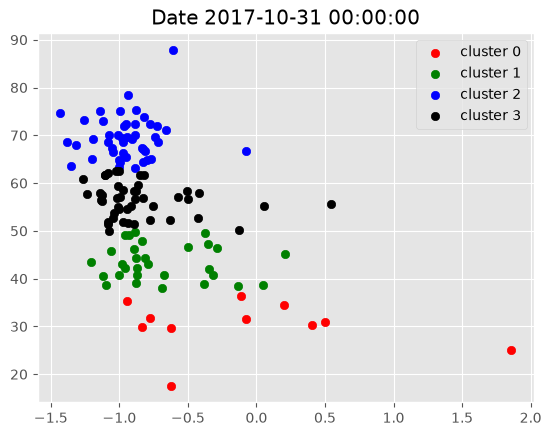

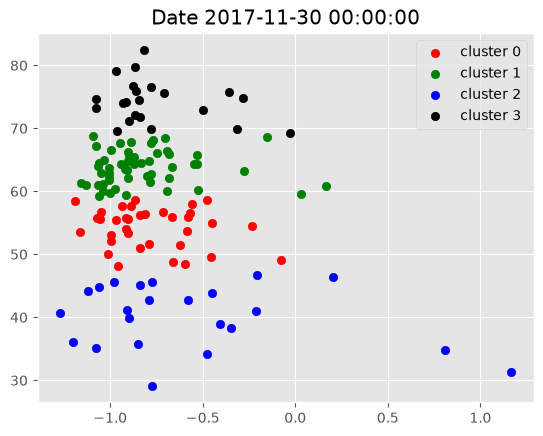

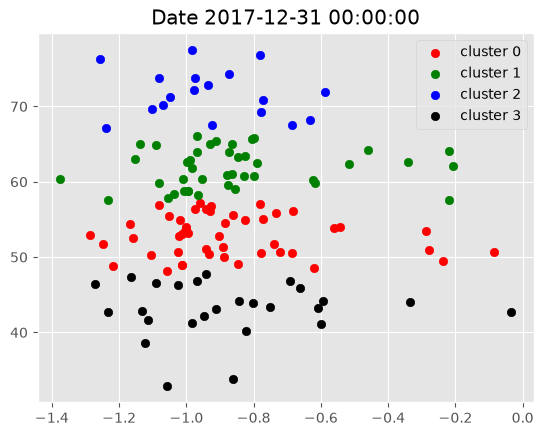

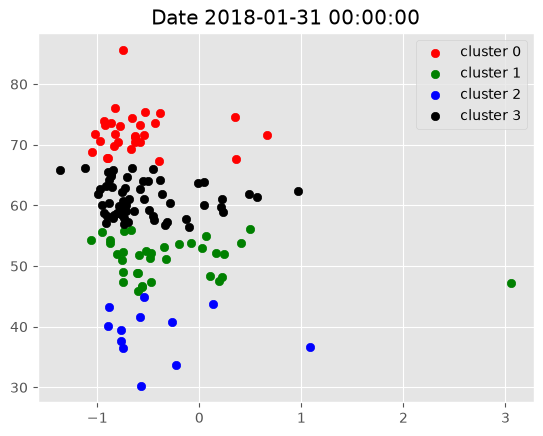

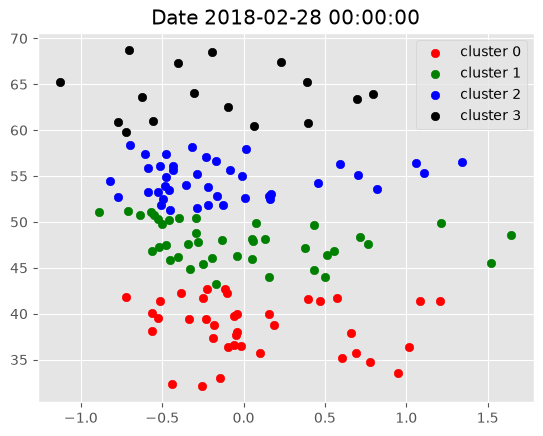

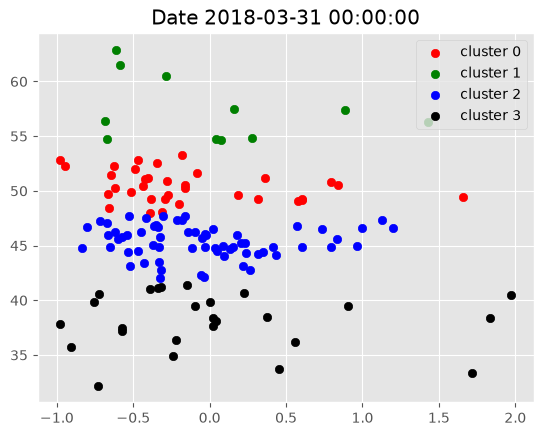

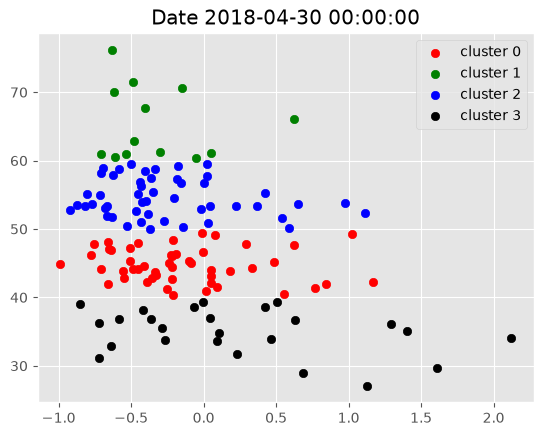

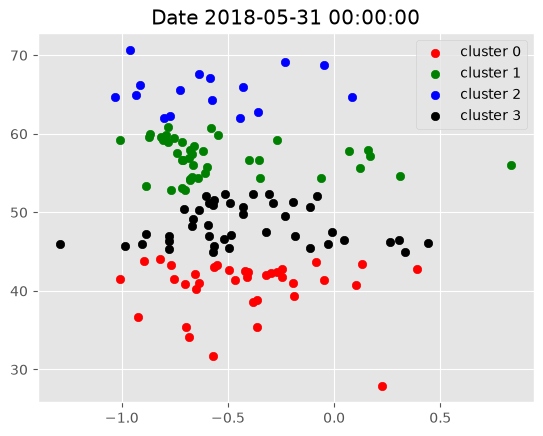

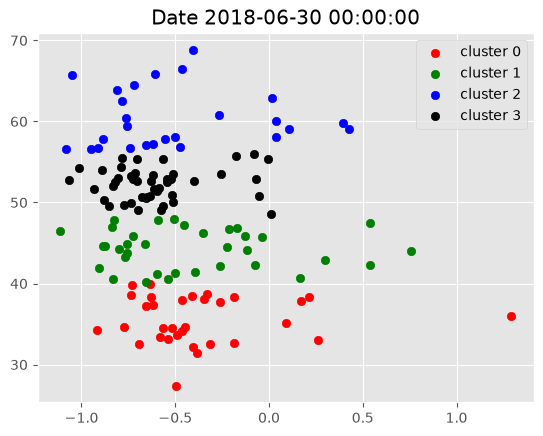

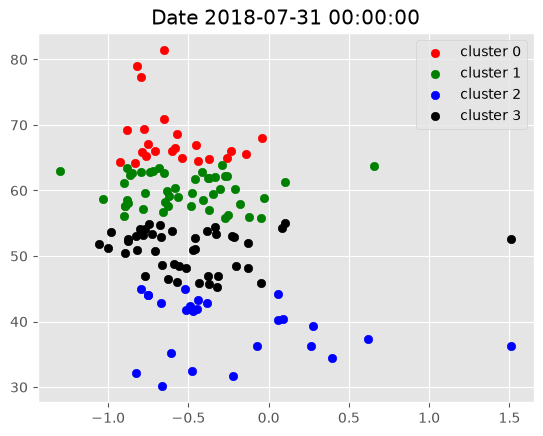

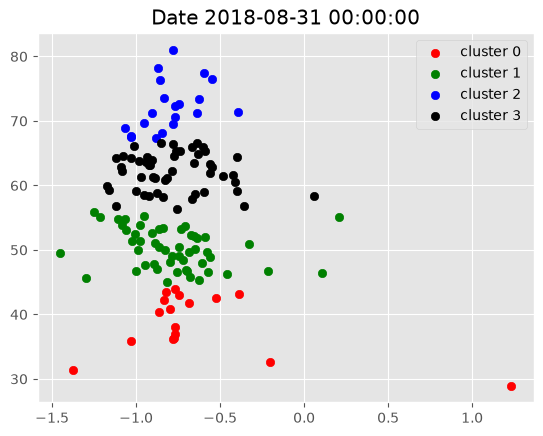

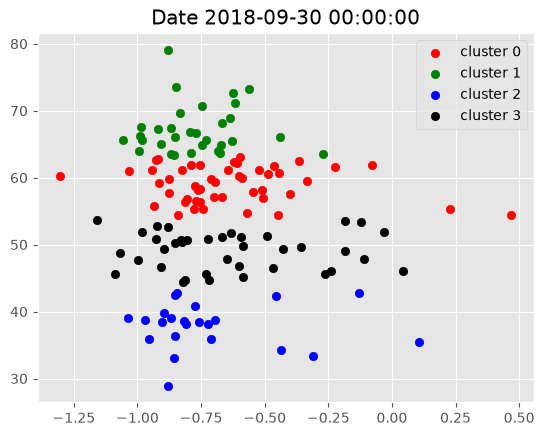

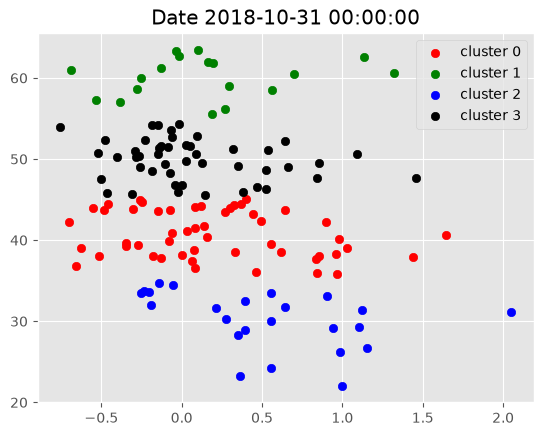

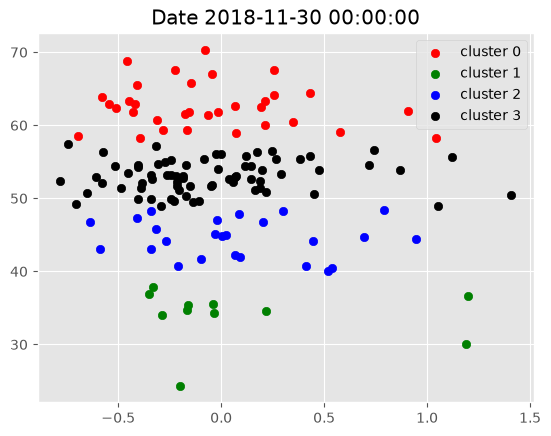

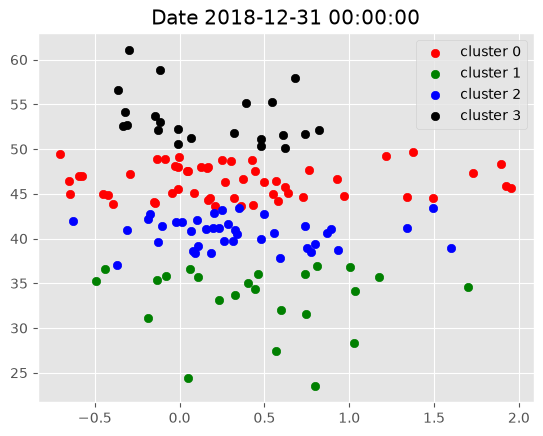

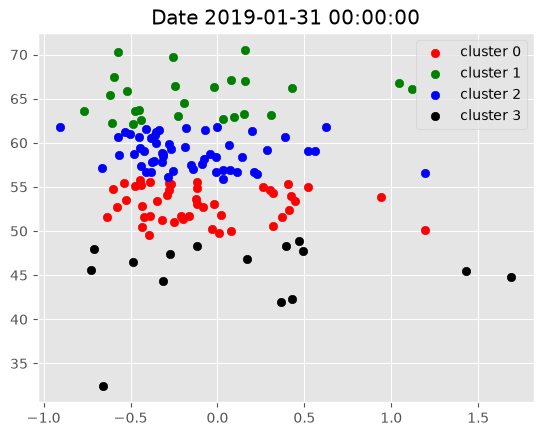

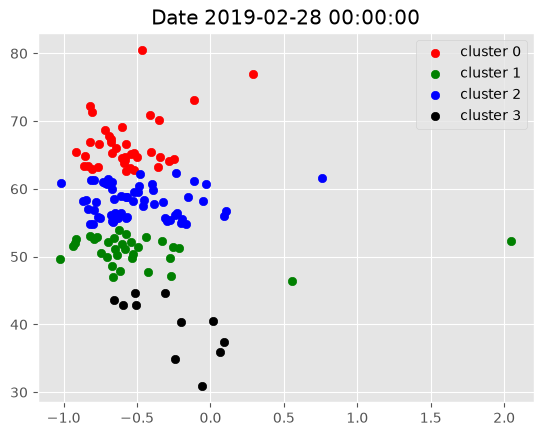

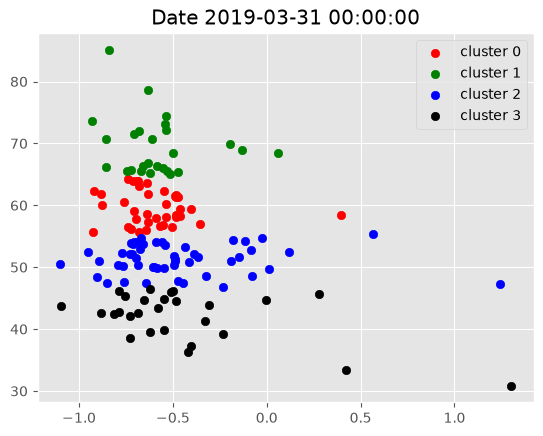

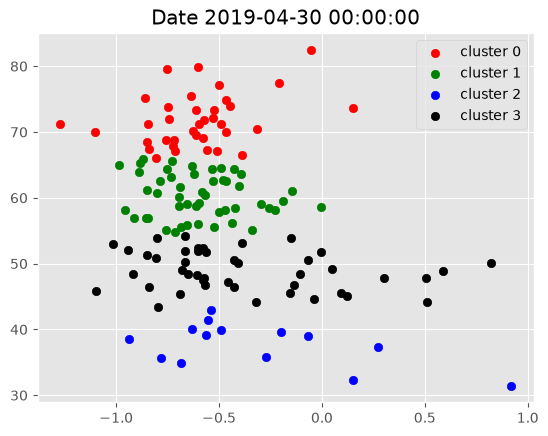

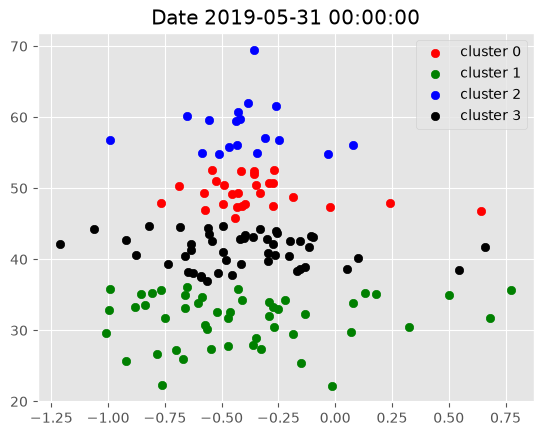

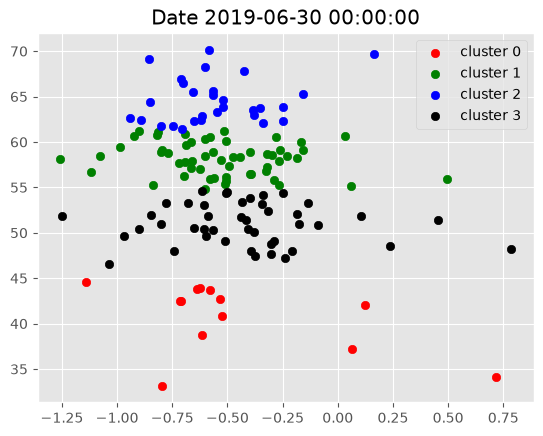

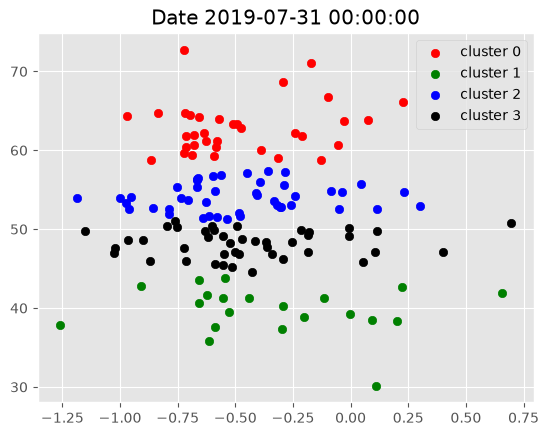

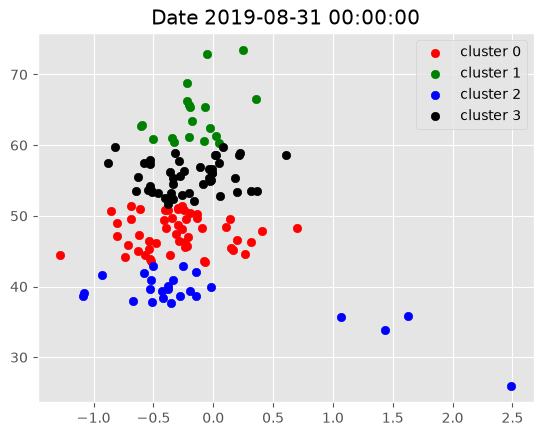

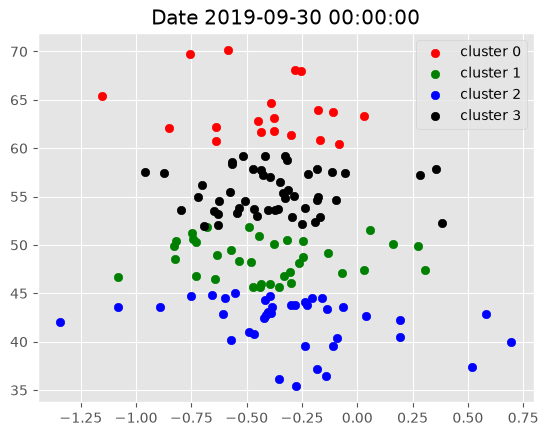

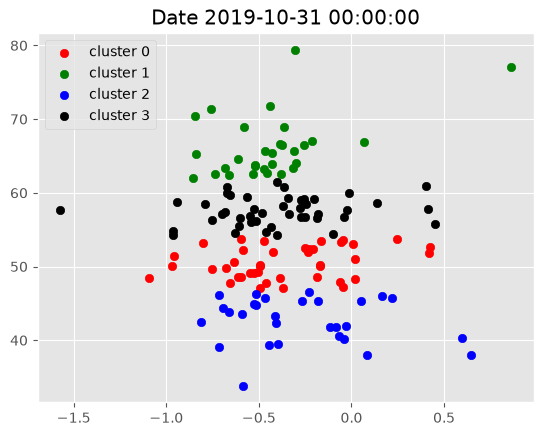

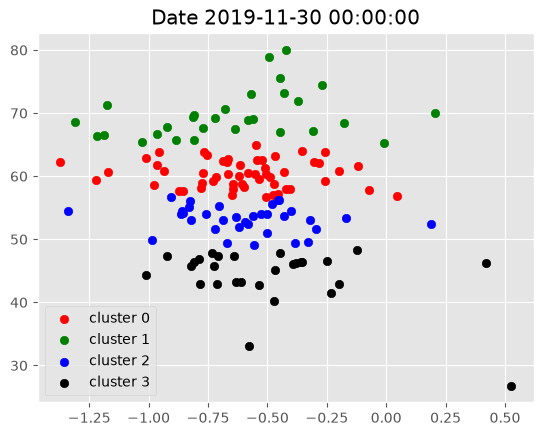

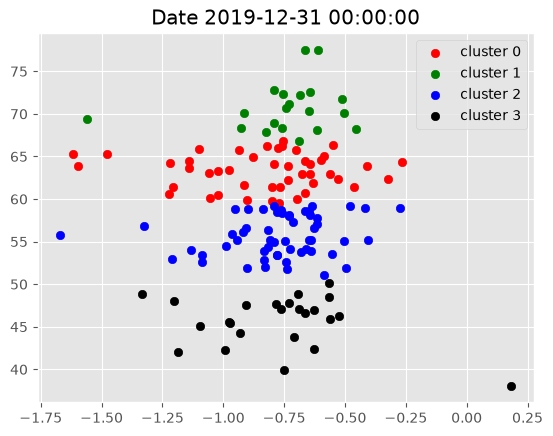

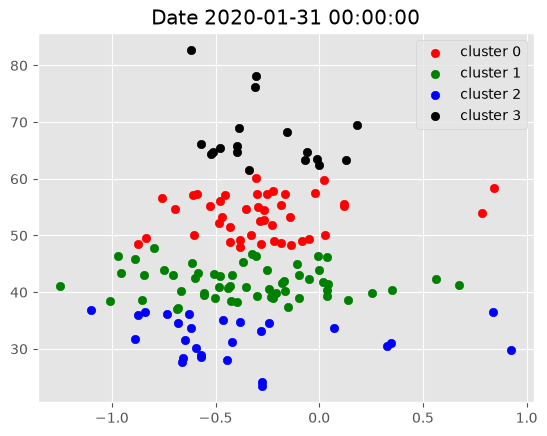

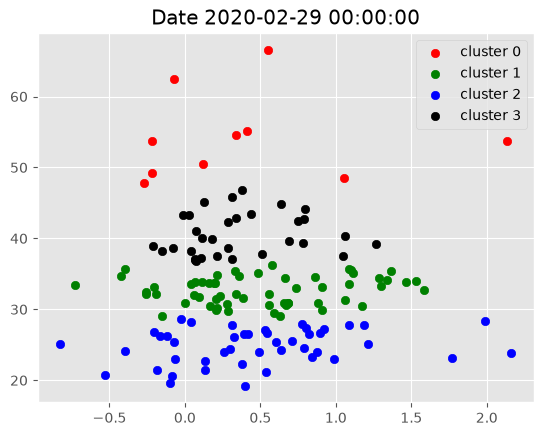

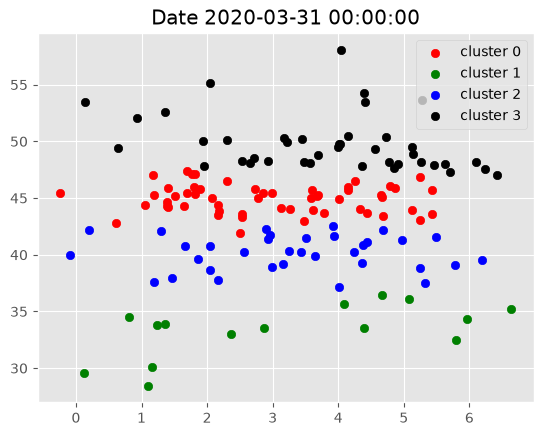

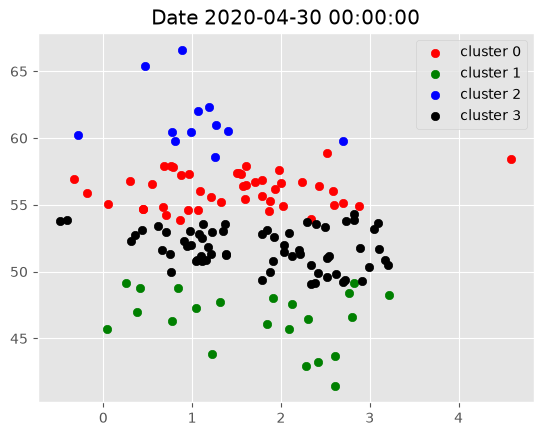

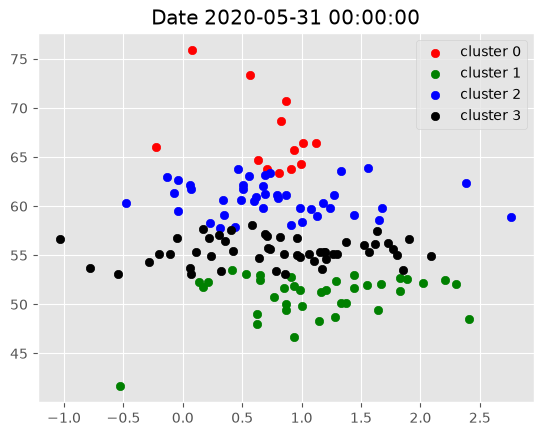

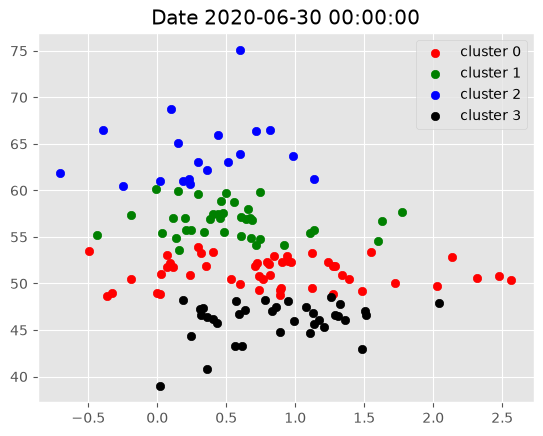

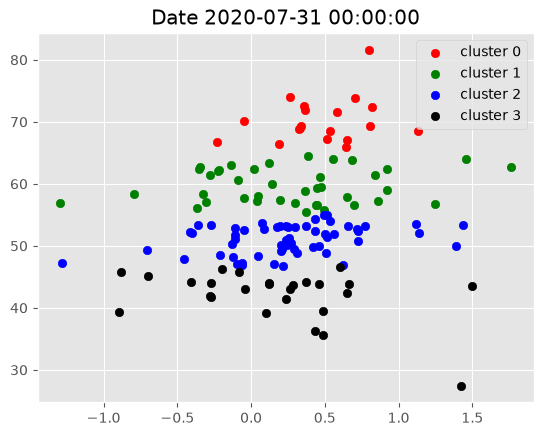

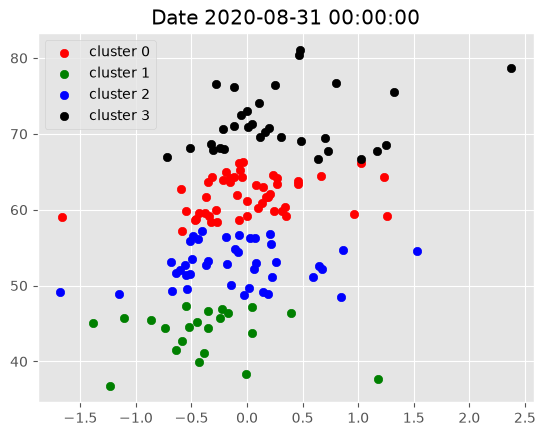

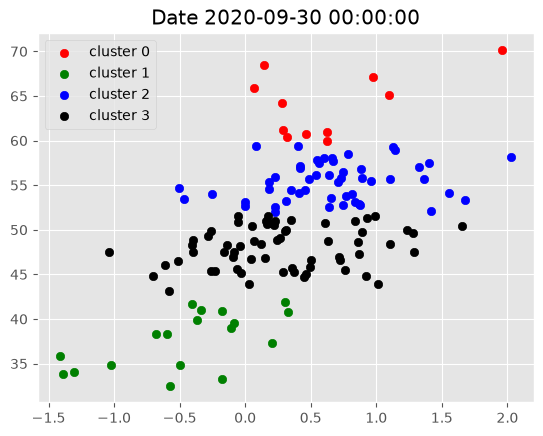

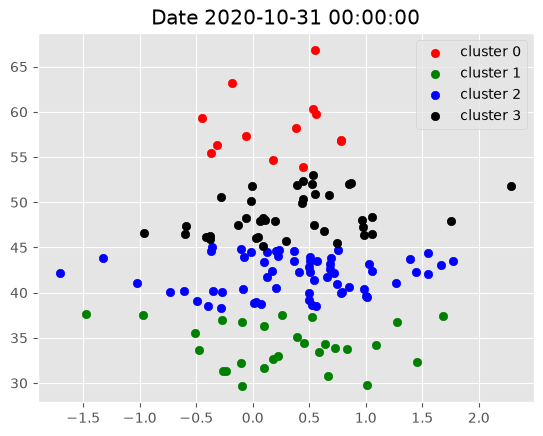

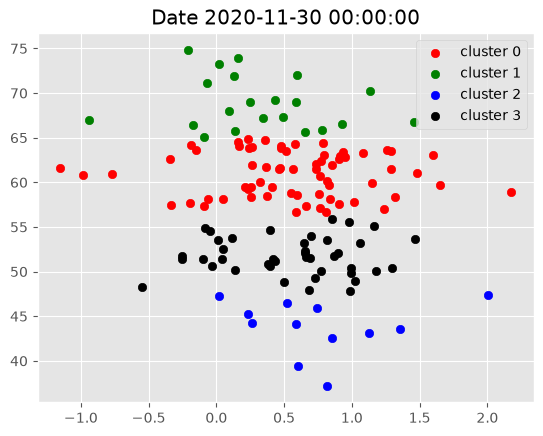

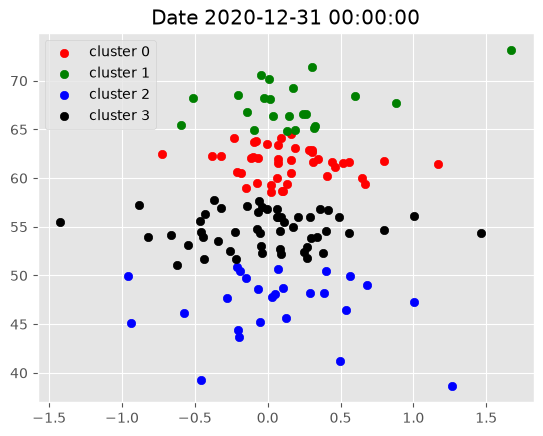

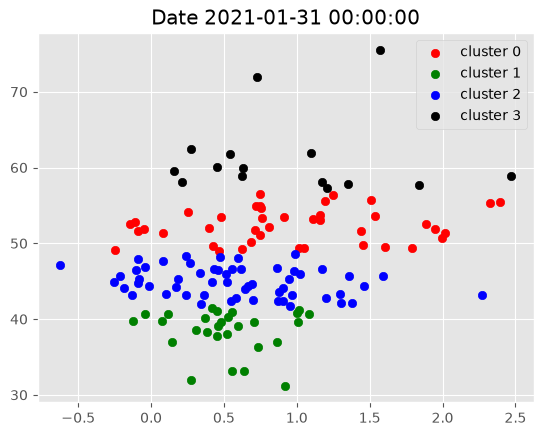

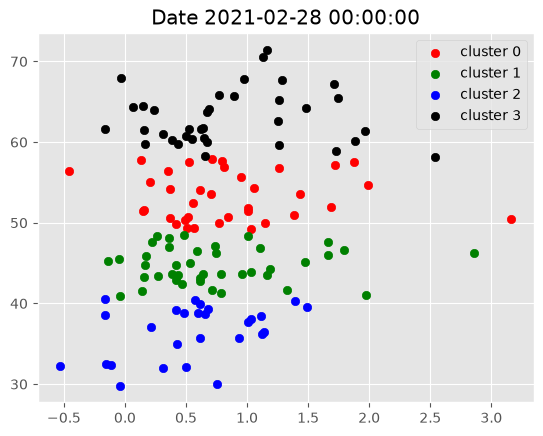

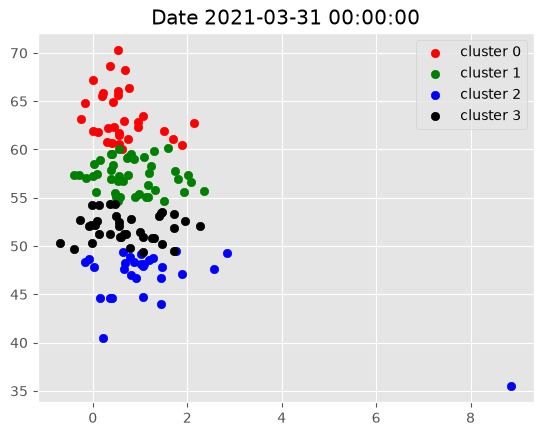

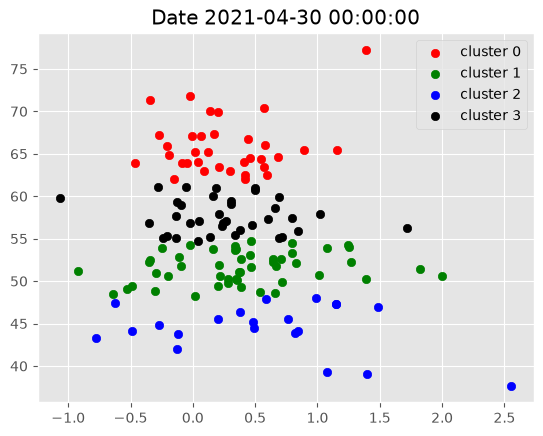

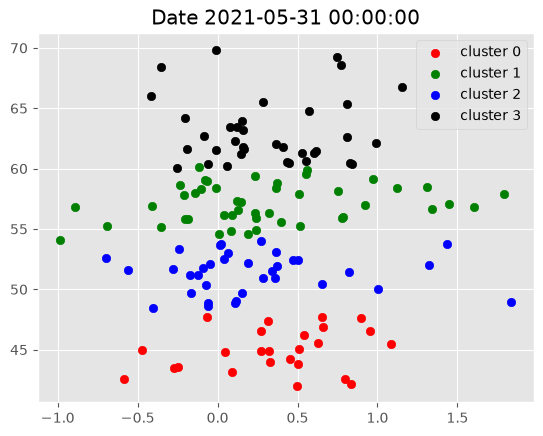

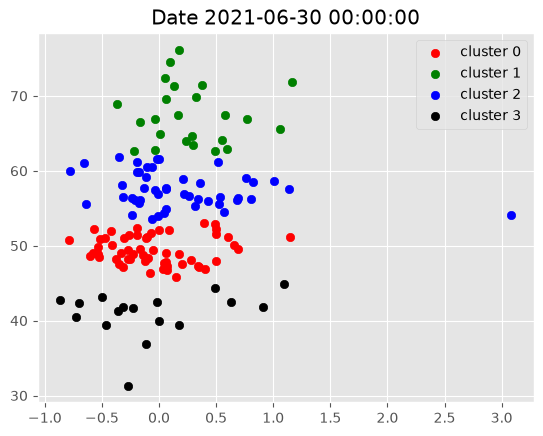

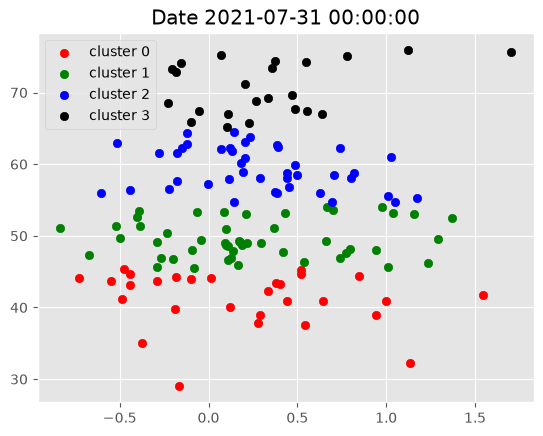

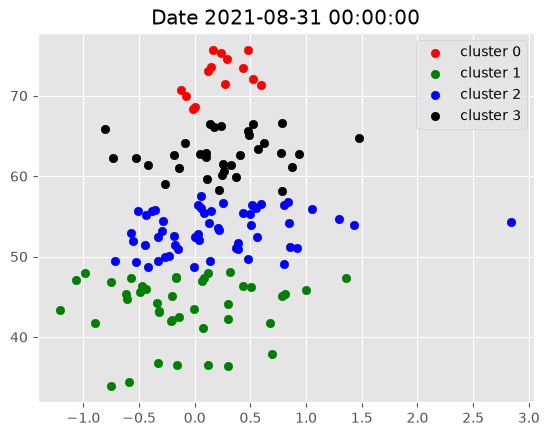

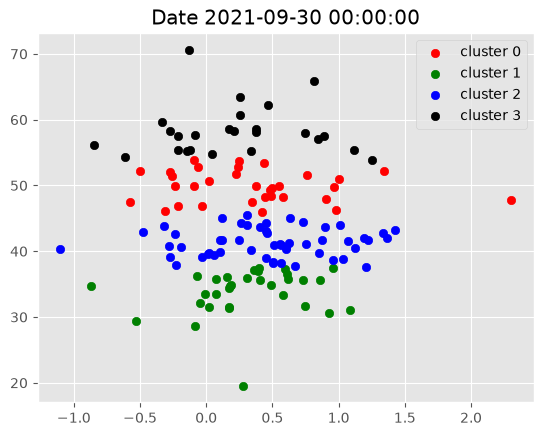

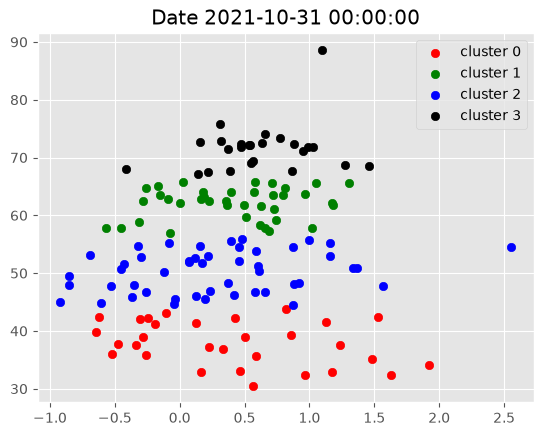

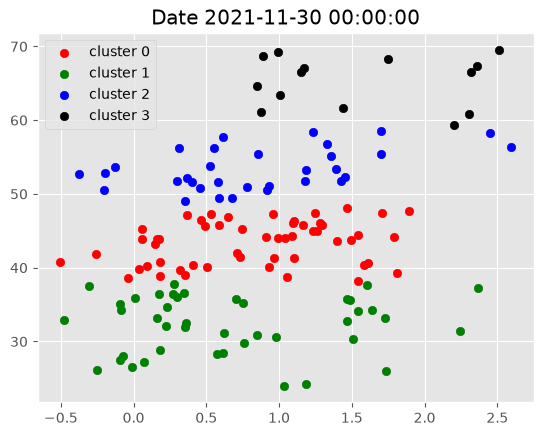

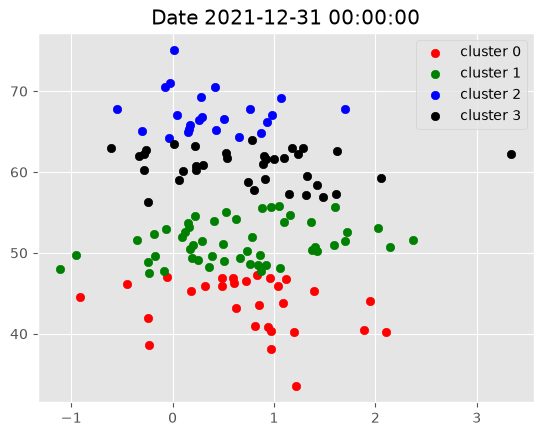

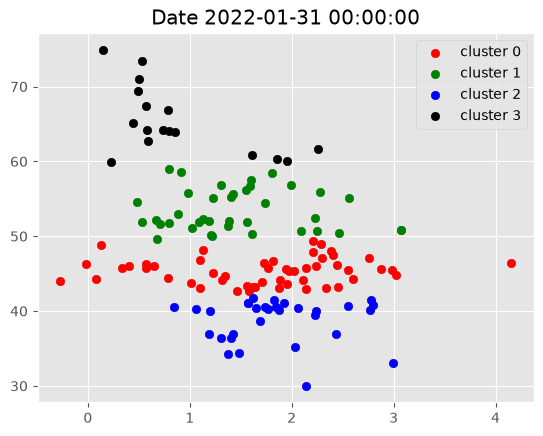

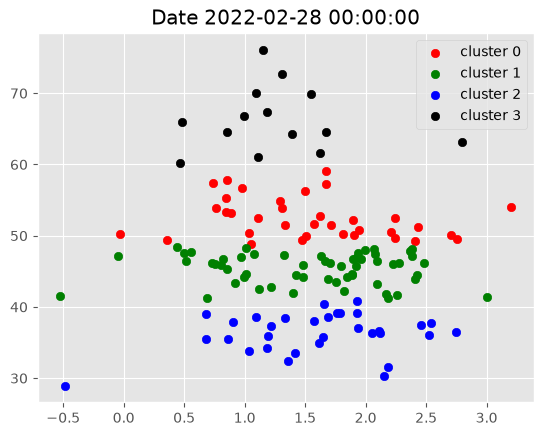

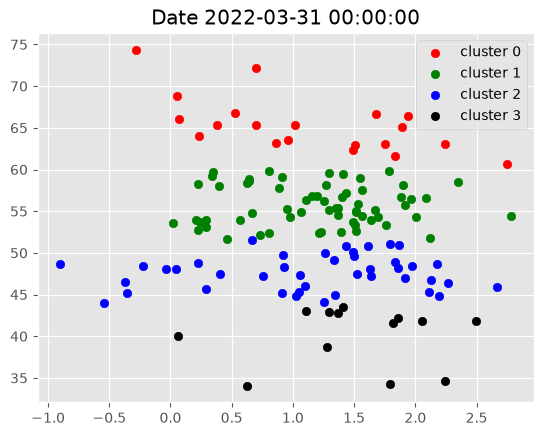

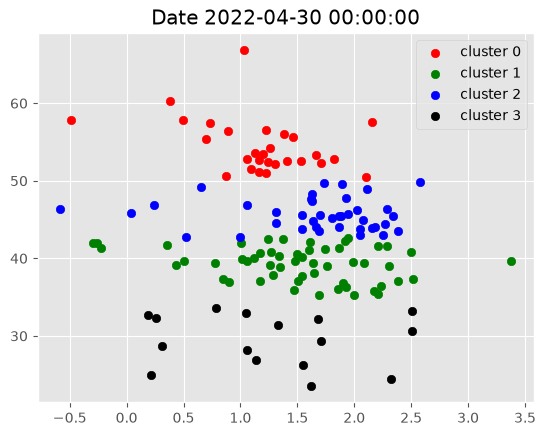

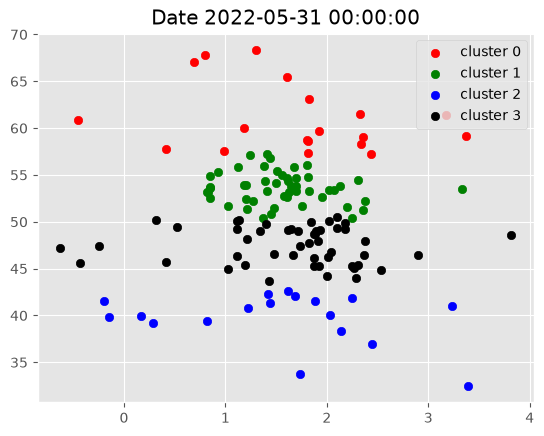

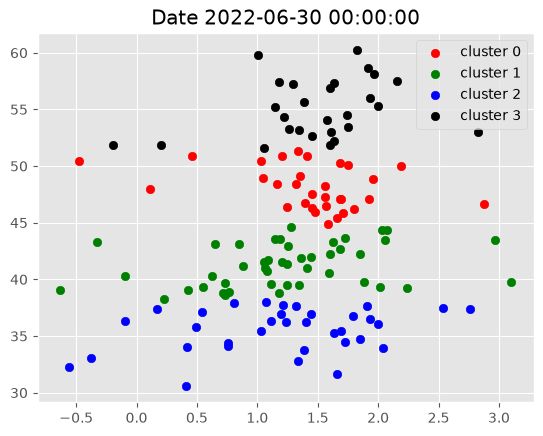

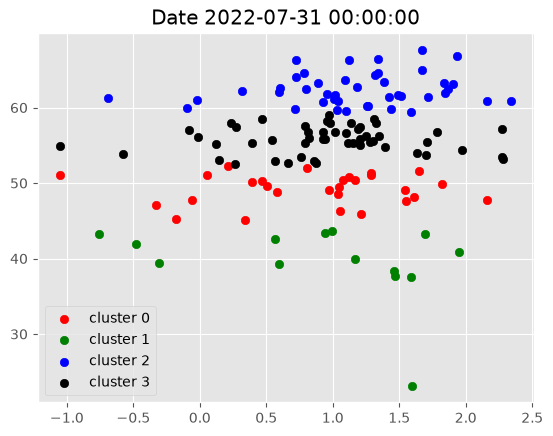

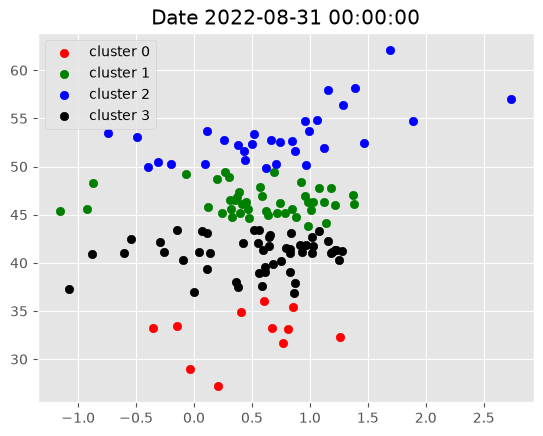

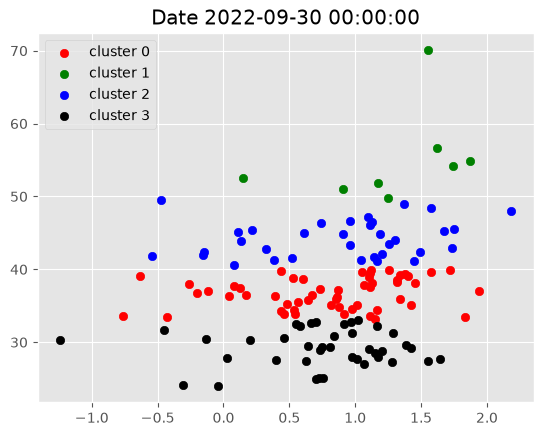

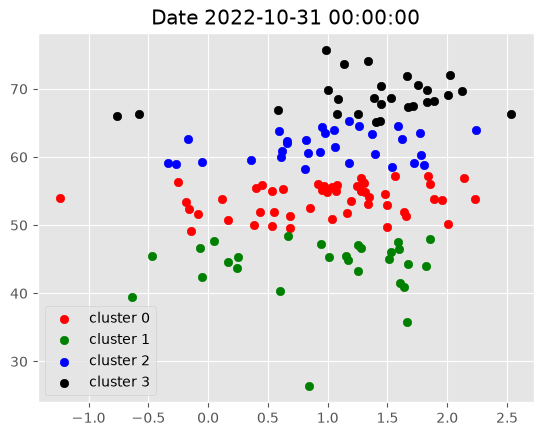

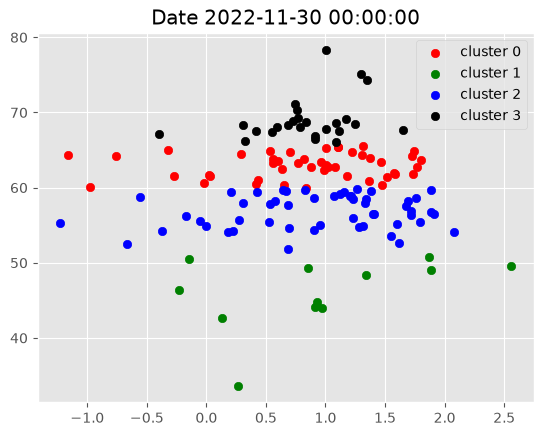

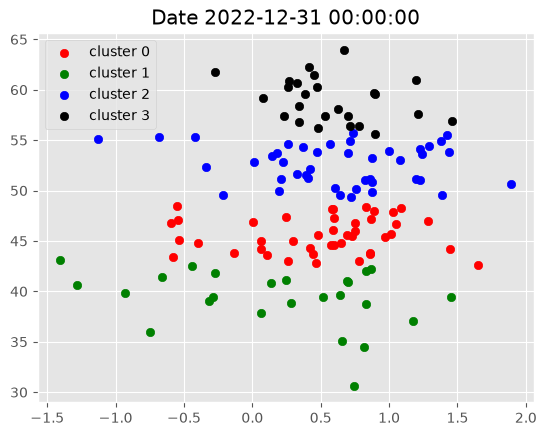

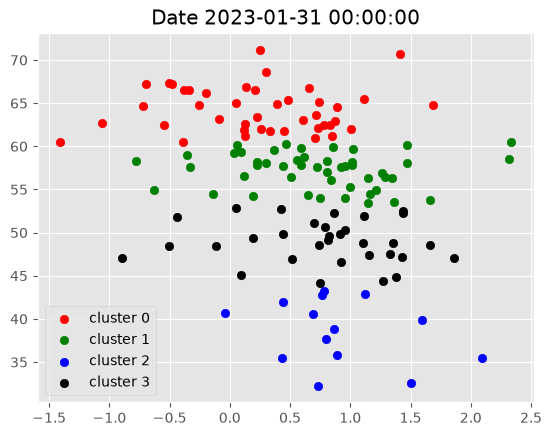

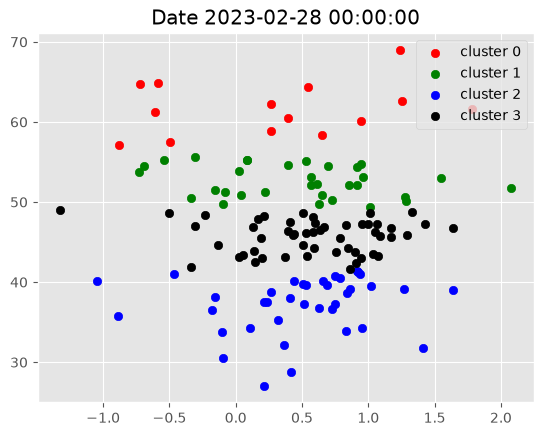

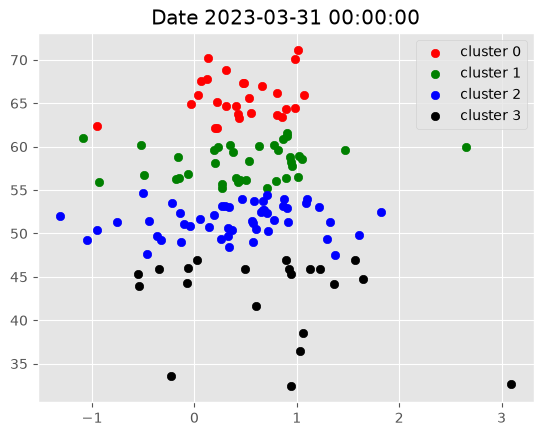

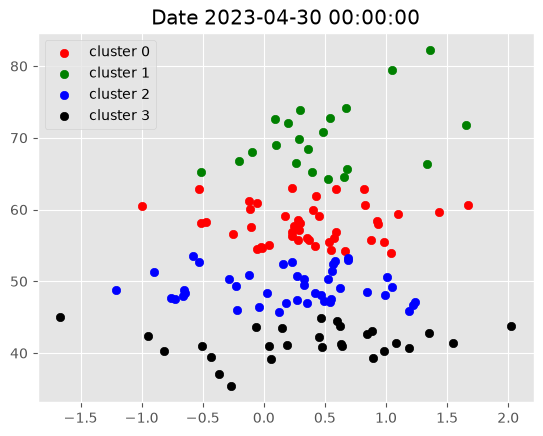

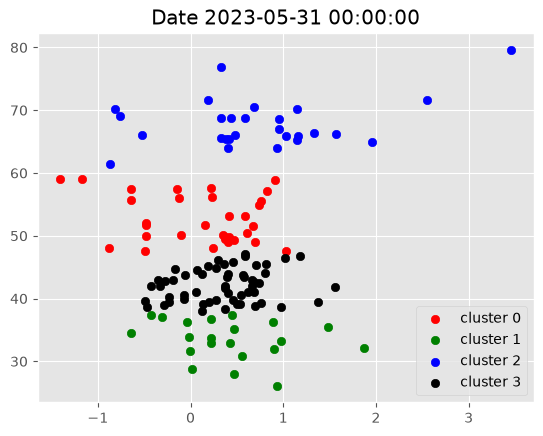

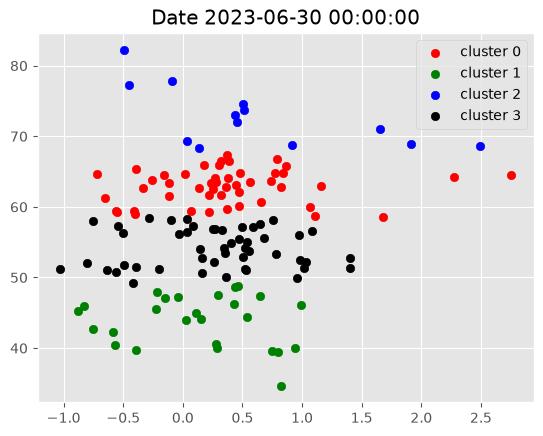

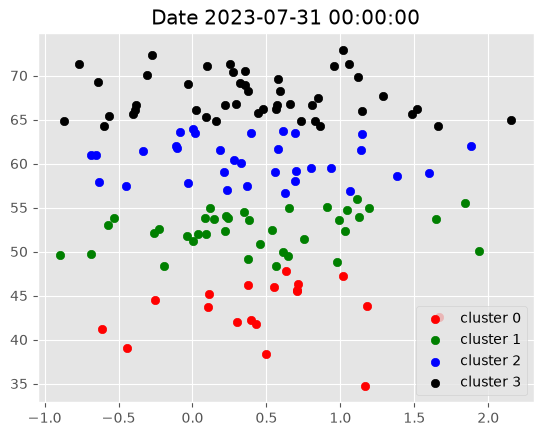

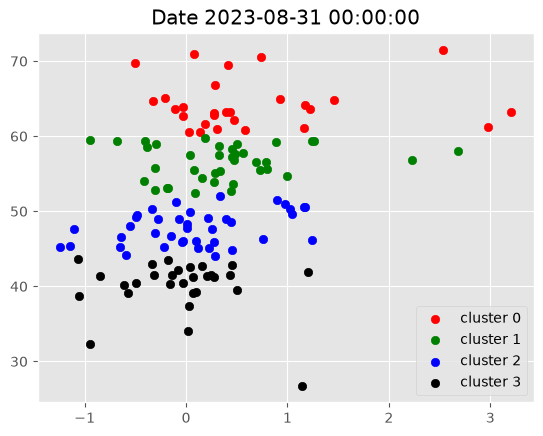

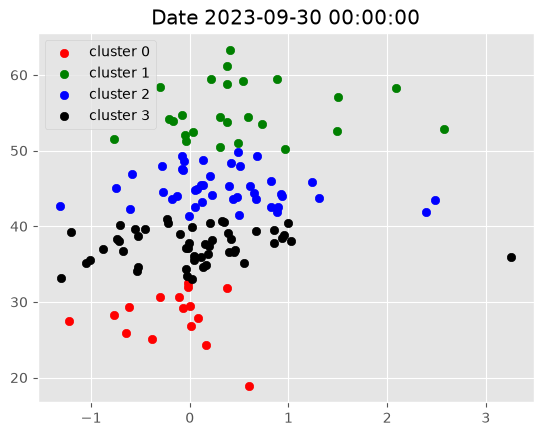

In [24]:
plt.style.use('ggplot')

for i in data.index.get_level_values('date').unique().tolist():

    g=data.xs(i, level =0)

    plt.title(f'Date {i}')

    plot_clusters(g)

Apply pre-defined centroids


In [25]:
target_rsi_values = [42, 50, 59, 67]

initial_centroids = np.zeros((len(target_rsi_values), 18))

initial_centroids[:, 6] = target_rsi_values

initial_centroids

array([[ 0.,  0.,  0.,  0.,  0.,  0., 42.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0., 50.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0., 59.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0., 67.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.]])

# For each month select assets based on the cluster and form a portfolio based on Efficient Frontier max sharpe ratio optimization

- First we will filter only stocks corresponding to the cluster we choose based on our hypothesis.
- Momentum is persistent and my idea would be that stocks clustered around RSI 70 centroid should continue to outperform in the following month - thus I would select stocks corresponding to cluster 3


In [26]:
filtered_df = data[data['cluster']==3].copy()

filtered_df = filtered_df.reset_index(level =1)

filtered_df.index = filtered_df.index+pd.DateOffset(1)

filtered_df = filtered_df.reset_index().set_index(['date', 'ticker'])

dates = filtered_df.index.get_level_values('date').unique().tolist()

fixed_dates = {}

for d in dates:

    fixed_dates[d.strftime('%Y-%m-%d')] = filtered_df.xs(d, level=0).index.tolist()

fixed_dates

{'2017-11-01': ['ABBV',
  'ABT',
  'AIG',
  'AZO',
  'BA',
  'BKNG',
  'BLK',
  'BRK-B',
  'C',
  'CCL',
  'COST',
  'CSCO',
  'DD',
  'DG',
  'EA',
  'EBAY',
  'F',
  'FDX',
  'GM',
  'GS',
  'HD',
  'HON',
  'HUM',
  'IBM',
  'JNJ',
  'KO',
  'LOW',
  'MDLZ',
  'MDT',
  'MS',
  'NFLX',
  'NKE',
  'NOC',
  'ORLY',
  'OXY',
  'PANW',
  'RTX',
  'SBUX',
  'SCHW',
  'TMO',
  'UNP',
  'USB',
  'WDC',
  'WFC',
  'WYNN'],
 '2017-12-01': ['AXP',
  'AZO',
  'BA',
  'BLK',
  'COST',
  'CSCO',
  'DE',
  'DLTR',
  'ELV',
  'HD',
  'HON',
  'JPM',
  'KR',
  'MAR',
  'MMM',
  'NKE',
  'SCHW',
  'UNH',
  'UNP',
  'VLO',
  'VZ',
  'WMT'],
 '2018-01-01': ['AAPL',
  'AIG',
  'AMAT',
  'AMGN',
  'AVGO',
  'BKNG',
  'BMY',
  'BSX',
  'CMG',
  'CRM',
  'CTSH',
  'EA',
  'EXPE',
  'GE',
  'GILD',
  'GM',
  'ISRG',
  'LLY',
  'LRCX',
  'MET',
  'MU',
  'NVDA',
  'ORCL',
  'REGN',
  'TSLA',
  'WDC'],
 '2018-02-01': ['ABBV',
  'ACN',
  'ADBE',
  'AIG',
  'AMD',
  'AZO',
  'BKNG',
  'BLK',
  'BSX',
  'C',
  '

# Define portfolio optimization function

- We will define a function which optimizes portfolio weights using PyPortfolioOpt package and EfficientFrontier optimizer to maximize the sharpe ratio.
- To optimize the weights of a given portfolio we would need to supply last 1 year prices to the function.
- Apply single stock bounds constraint for diversification (minimum half of equally weight and maximum 10% of portfolio)


In [27]:
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import risk_models
from pypfopt import expected_returns

def optimize_weights(prices, lower_bound=0):
    returns = expected_returns.mean_historical_return(prices = prices,
                                                      frequency = 252)
    
    cov = risk_models.sample_cov(prices = prices,
                                 frequency =252)
    
    ef = EfficientFrontier(expected_returns = returns,
                           cov_matrix = cov,
                           weight_bounds = (lower_bound, 1),
                           solver = 'SCS')
    
    weights = ef.max_sharpe()

    return ef.clean_weights()

Download Fresh Daily Prices Data only for short listed stocks


In [34]:
stocks = data.index.get_level_values('ticker').unique().tolist()
new_df = yf.download(tickers = stocks,
                     start = data.index.get_level_values('date').unique()[0]-pd.DateOffset(months=12),
                     end=data.index.get_level_values('date').unique()[-1])

new_df

[*********************100%***********************]  156 of 156 completed


Price            Close                                                 \
Ticker            AAPL        ABBV        ABT         ACN        ADBE   
Date                                                                    
2016-10-31   25.987364   37.609138  32.946453  100.402321  107.510002   
2016-11-01   25.518154   38.060886  32.786926  100.315956  106.870003   
2016-11-02   25.541039   38.290115  32.493069  102.449409  105.889999   
2016-11-03   25.267271   37.683308  32.224380  101.015579  107.169998   
2016-11-04   25.039515   37.784435  32.820507  101.257431  106.199997   
...                ...         ...        ...         ...         ...   
2023-09-25  173.880096  140.422852  92.220901  303.737183  511.600006   
2023-09-26  169.811615  139.750931  91.047676  297.623932  506.299988   
2023-09-27  168.300674  139.042679  90.385384  301.236389  502.600006   
2023-09-28  168.557449  138.243622  92.835899  288.195312  504.670013   
2023-09-29  169.070969  135.347092  91.634293  294.270294  509.899994   

Price                                                                  ...  \
Ticker             ADP        ADSK        AIG        AMAT         AMD  ...   
Date                                                                   ...   
2016-10-31   70.377029   72.279999  48.257797   26.165358    7.230000  ...   
2016-11-01   70.263855   70.099998  47.460011   26.003395    7.090000  ...   
2016-11-02   72.737488   68.680000  47.358337   25.724468    6.760000  ...   
2016-11-03   72.212036   67.610001  45.481209   25.436546    6.700000  ...   
2016-11-04   72.009949   69.440002  44.878967   25.391548    6.560000  ...   
...                ...         ...        ...         ...         ...  ...   
2023-09-25  224.809235  205.669998  58.498798  133.567902   97.379997  ...   
2023-09-26  222.205414  201.660004  57.679642  131.113419   95.959999  ...   
2023-09-27  227.253830  202.279999  57.444252  132.071732   98.070000  ...   
2023-09-28  227.890701  207.889999  57.698471  135.161819  102.760002  ...   
2023-09-29  225.333725  206.910004  57.058216  135.386719  102.820000  ...   

Price        Volume                                                           \
Ticker          VLO     VRTX        VZ     WDAY      WDC       WFC       WMT   
Date                                                                           
2016-10-31  4969500  1928200  12459400  1147300  4449514  20115900  19167000   
2016-11-01  7816800  2458200  13229400  1091400  5055315  20020200  26515800   
2016-11-02  7317600  2580400  16488200  1127800  5578033  19566600  22935900   
2016-11-03  3855900  2371000  12605100   633300  4223810  14982700  20411700   
2016-11-04  3729900  1902100  14410200   892600  3579509  27391600  21786300   
...             ...      ...       ...      ...      ...       ...       ...   
2023-09-25  3241900   698100  17616900   894200  3553446  10624000  10459500   
2023-09-26  4936800   633600  18841600  1217300  4724565  15219400  14435700   
2023-09-27  3644000   860600  22083500  2338100  3370739  11815500  15711000   
2023-09-28  3587300   578900  18772100  9196300  4342086  12454600  11617200   
2023-09-29  4302200   896800  19787600  4066600  3323376  13124500  18842400   

Price                                    
Ticker         WYNN       XOM       XYZ  
Date                                     
2016-10-31  1341600  16663800   2960600  
2016-11-01  3722300  13050600   8190900  
2016-11-02  2542400  11226100  19503200  
2016-11-03  9050400   8836500   7371500  
2016-11-04  3223800  13877100  13462800  
...             ...       ...       ...  
2023-09-25  1387800  11316000   8841300  
2023-09-26  1454000  11805400  10168200  
2023-09-27  2050000  23976200  11656100  
2023-09-28  1290400  16808100  16585100  
2023-09-29  1326800  18813600  11965300  

[1740 rows x 780 columns]

- calculate daily returns for each stock which could land up in our portfolio.
- Then loop over each month start, select the stocks for the month and calculate their weights for the next month.
- If the maximum sharpe ratio optimization fails for a given month, apply equally-weighted weights.
- Calculate each day portfolio return.


In [38]:
returns_dataframe = np.log(new_df['Close']).diff()

portfolio_df = pd.DataFrame()

for start_date in fixed_dates.keys():

    try: 
        end_date = (pd.to_datetime(start_date)+pd.offsets.MonthEnd(0)).strftime('%Y-%m-%d')

        cols = fixed_dates[start_date]

        optimization_start_date = (pd.to_datetime(start_date)-pd.DateOffset(months=12)).strftime('%Y-%m-%d')

        optimization_end_date = (pd.to_datetime(start_date)+pd.DateOffset(days=1)).strftime('%Y-%m-%d')

        optimization_df = new_df[optimization_start_date:optimization_end_date]['Close'][cols]

        success = False

        try: 
            weights = optimize_weights(prices = optimization_df,
                           lower_bound = round(1/(len(optimization_df.columns)*2), 3))

            weights = pd.DataFrame(weights, index=pd.Series(0))

        except:
            print(f'Max Sharpe Optimization failed for {start_date}, Continuing with Equal-Weights')

        if success==False:
            weights = pd.DataFrame([1/len(optimization_df.columns) for i in range(len(optimization_df.columns))],
                                   index = optimization_df.columns.tolist(),
                                   columns=pd.Series(0)).T

        temp_df = returns_dataframe[start_date:end_date]

        s1 = temp_df.stack().to_frame('return').reset_index(level=0)
        s1.index.name = 'ticker'

        s2 = weights.stack().to_frame('weight').reset_index(level=0, drop = True)
        s2.index.name = 'ticker'

        temp_df = s1.merge(s2, left_index=True, right_index=True)\
                    .reset_index().set_index(['Date', 'ticker'])

        temp_df['weighted_return'] = temp_df['return']*temp_df['weight']

        temp_df = temp_df.groupby(level=0)['weighted_return'].sum().to_frame('Strategy Return')

        portfolio_df = pd.concat([portfolio_df, temp_df], axis=0)

    
    except Exception as e:
        print(e)

portfolio_df = portfolio_df.drop_duplicates()

portfolio_df


Max Sharpe Optimization failed for 2022-05-01, Continuing with Equal-Weights
Max Sharpe Optimization failed for 2022-10-01, Continuing with Equal-Weights


,Strategy Return
Date,
2017-11-01,0.000231
2017-11-02,0.002466
2017-11-03,-0.000152
2017-11-06,-0.001891
2017-11-07,-0.005358
...,...
2023-09-25,0.003466
2023-09-26,-0.013999
2023-09-27,-0.008380


In [39]:
print(portfolio_df.shape)
print(portfolio_df.head())
print(portfolio_df.dtypes)

(1487, 1)
            Strategy Return
Date                       
2017-11-01         0.000231
2017-11-02         0.002466
2017-11-03        -0.000152
2017-11-06        -0.001891
2017-11-07        -0.005358
Strategy Return    float64
dtype: object


In [42]:
optimization_df = new_df['2016-11-01': '2017-10-30']['Close'][fixed_dates['2017-11-01']]
optimization_df

Ticker,ABBV,ABT,AIG,AZO,BA,BKNG,BLK,BRK-B,C,CCL,...,PANW,RTX,SBUX,SCHW,TMO,UNP,USB,WDC,WFC,WYNN
Date,,,,,,,,,,,,,,,,,,,,,
2016-11-01,38.060886,32.786926,47.460011,734.450012,131.028259,57.603886,269.508362,143.630005,36.410934,42.694939,...,25.301666,51.287964,42.563221,27.925768,142.052750,70.886642,30.976734,38.322563,35.122334,87.517242
2016-11-02,38.290115,32.493069,47.358337,738.030029,129.500900,56.752987,267.650879,143.190002,36.113335,42.562668,...,24.469999,51.051659,42.952366,27.405193,141.838745,71.531876,30.656240,36.956757,34.837421,85.993706
2016-11-03,37.683308,32.224380,45.481209,738.869995,128.829285,56.469086,269.650726,143.639999,35.971516,42.606758,...,24.266666,50.805302,41.971386,27.484602,142.111130,71.596397,30.691076,36.916588,34.914417,77.984146
2016-11-04,37.784435,32.820507,44.878967,731.650024,128.387650,55.926426,273.334137,142.949997,35.956570,42.359863,...,24.666668,50.946072,42.765888,27.264017,142.587830,71.588333,30.607468,36.836254,34.344566,78.438522
2016-11-07,39.719513,33.466999,46.365021,732.869995,131.598709,58.127308,282.693054,146.910004,37.188221,43.197544,...,25.405001,51.810848,44.176563,28.508106,147.685410,73.193314,31.297239,38.610443,34.960625,78.278152
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-10-24,64.076927,47.576576,51.988392,585.830017,252.140625,75.874176,383.736237,189.779999,55.981628,60.078640,...,24.873333,61.639050,44.793613,40.194073,189.785553,93.173347,38.598793,60.301620,43.582211,131.585358
2017-10-25,64.132828,47.671078,51.964447,587.400024,244.955612,75.737526,380.034149,188.710007,55.514099,59.554008,...,24.758333,61.252975,44.694595,39.713768,194.950455,91.002899,38.548958,59.889957,43.448524,130.314056
2017-10-26,62.588387,47.662483,51.764889,590.890015,245.761276,76.149048,383.541809,188.610001,55.642292,60.241455,...,24.799999,61.736835,45.313511,40.336380,195.633972,96.119576,38.662876,61.323914,43.739491,131.975784


<Axes: xlabel='Date'>

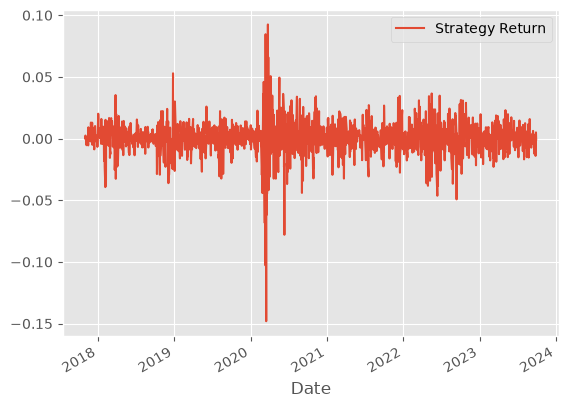

In [43]:
portfolio_df.plot()

# Visualize portfolio returns and compare to SP500 returns


In [45]:
spy=yf.download(tickers='SPY',
                start='2015-01-01',
                end=dt.date.today())

spy_ret = np.log(spy['Close']).diff().dropna().rename({'Close':'SPY Buy&Hold'}, axis=1)

portfolio_df = portfolio_df.merge(spy_ret,
                                  left_index=True,
                                  right_index=True)

portfolio_df

[*********************100%***********************]  1 of 1 completed


,Strategy Return,SPY
Date,,
2017-11-01,0.000231,0.001321
2017-11-02,0.002466,0.000388
2017-11-03,-0.000152,0.003333
2017-11-06,-0.001891,0.001547
2017-11-07,-0.005358,-0.000696
...,...,...
2023-09-25,0.003466,0.004197
2023-09-26,-0.013999,-0.014800
2023-09-27,-0.008380,0.000399


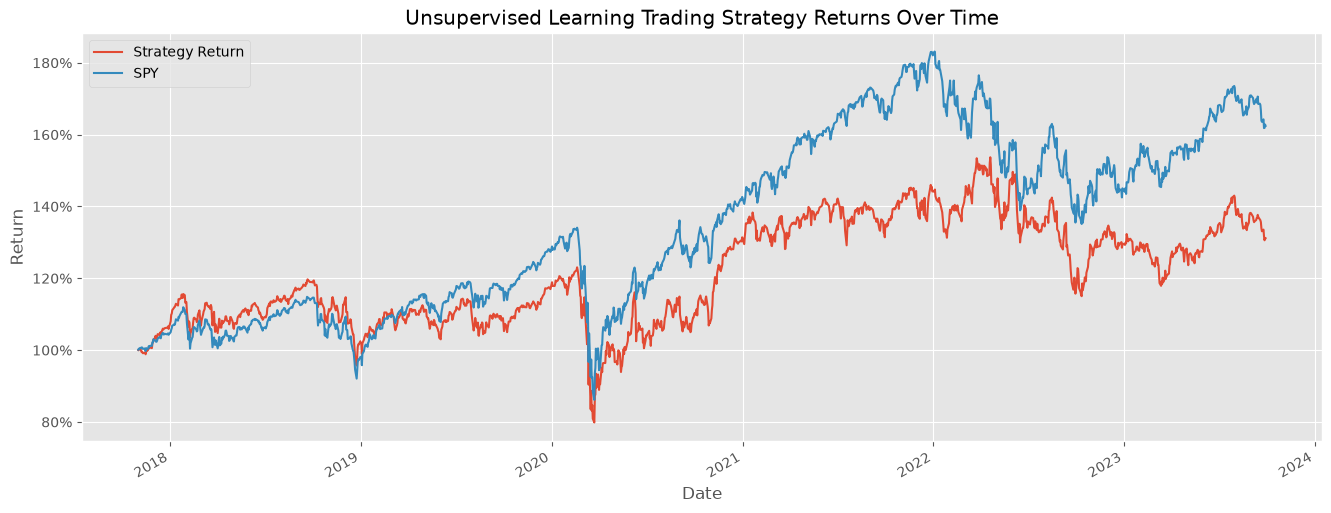

In [50]:
import matplotlib.ticker as mtick

plt.style.use('ggplot')

portfolio_cumulative_return = np.exp(np.log1p(portfolio_df).cumsum())

portfolio_cumulative_return.plot(figsize=(16, 6))

plt.title('Unsupervised Learning Trading Strategy Returns Over Time')

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1))

plt.ylabel('Return')

plt.show()